## Выгрузка landsat для одной конкретной точки

In [6]:
import ee
import os
import time
import numpy as np
import pandas as pd
from datetime import datetime

# --- authentication ---
try:
    ee.Initialize(project="ee-asshakaps")  # замените на ваш проект gee
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project="ee-asshakaps")  # замените на ваш проект gee

# --- earth engine configuration ---
START_DATE = "2019-01-01"
END_DATE = "2025-03-01"

TARGET_LON = 131.417
TARGET_LAT = 43.0
FIRE_PERIODS = [
    ("2019-03-15", "2019-04-30"),
    ("2020-03-01", "2020-04-15"),
    ("2021-03-10", "2021-05-01"),
    ("2022-03-05", "2022-04-20"),
    ("2023-03-20", "2023-04-25"),
    ("2024-03-01", "2024-04-30"),
    ("2025-03-01", "2025-04-29"),
]

BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50


# --- earth engine functions ---
def get_s2_sr_cld_col(aoi, start_date, end_date):
    s2_sr_col = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", CLOUD_FILTER))
    )
    s2_cloudless_col = (
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
    )
    return ee.ImageCollection(
        ee.Join.saveFirst("s2cloudless").apply(
            **{
                "primary": s2_sr_col,
                "secondary": s2_cloudless_col,
                "condition": ee.Filter.equals(
                    **{"leftField": "system:index", "rightField": "system:index"}
                ),
            }
        )
    )


def add_cloud_bands(img):
    cld_prb = ee.Image(img.get("s2cloudless")).select("probability")
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename("clouds")
    return img.addBands(ee.Image([cld_prb, is_cloud]))


def add_shadow_bands(img):
    not_water = img.select("SCL").neq(6)
    SR_BAND_SCALE = 1e4
    dark_pixels = (
        img.select("B8")
        .lt(NIR_DRK_THRESH * SR_BAND_SCALE)
        .multiply(not_water)
        .rename("dark_pixels")
    )
    shadow_azimuth = ee.Number(90).subtract(
        ee.Number(img.get("MEAN_SOLAR_AZIMUTH_ANGLE"))
    )
    cld_proj = (
        img.select("clouds")
        .directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST * 10)
        .reproject(**{"crs": img.select(0).projection(), "scale": 100})
        .select("distance")
        .mask()
        .rename("cloud_transform")
    )
    shadows = cld_proj.multiply(dark_pixels).rename("shadows")
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))


def add_cld_shdw_mask(img):
    img_cloud = add_cloud_bands(img)
    img_cloud_shadow = add_shadow_bands(img_cloud)
    is_cld_shdw = (
        img_cloud_shadow.select("clouds").add(img_cloud_shadow.select("shadows")).gt(0)
    )
    is_cld_shdw = (
        is_cld_shdw.focalMin(radius=2, units="pixels")
        .focalMax(radius=BUFFER / 10, units="pixels")
        .reproject(**{"crs": img.select(0).projection(), "scale": 10})
        .rename("cloudmask")
    )
    return img_cloud_shadow.addBands(is_cld_shdw)


def apply_cld_shdw_mask(img):
    not_cld_shdw = img.select("cloudmask").Not()
    return img.select(BANDS).updateMask(not_cld_shdw)


# --- create output folder and csv path ---
output_folder = "landsat_output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

csv_filename = os.path.join(
    output_folder,
    f"timeseries_LHM_{TARGET_LAT}_{TARGET_LON}_{START_DATE}_to_{END_DATE}.csv",
)


# --- main processing ---
point_aoi = ee.Geometry.Point(TARGET_LON, TARGET_LAT)

print(f"Запрос данных для точки: LAT={TARGET_LAT}, LON={TARGET_LON}")
print(f"Период: с {START_DATE} по {END_DATE}")

try:
    s2_sr_cld_col = get_s2_sr_cld_col(point_aoi, START_DATE, END_DATE)
    s2_sr_cld_col_masked = s2_sr_cld_col.map(add_cld_shdw_mask).map(apply_cld_shdw_mask)

    collection_size = s2_sr_cld_col_masked.size().getInfo()
    if collection_size == 0:
        print("В коллекции нет изображений после фильтрации и маскирования.")
    else:
        print(f"Найдено изображений: {collection_size}")
        print("Извлечение временного ряда...")

        def set_time(image):
            return image.set("time_millis", image.get("system:time_start"))

        s2_sr_cld_col_masked_with_time = s2_sr_cld_col_masked.map(set_time)

        feature_collection = s2_sr_cld_col_masked_with_time.getRegion(
            geometry=point_aoi, scale=10
        ).getInfo()

        print("Данные получены. Обработка...")

        if not feature_collection or len(feature_collection) <= 1:
            print("Не удалось извлечь данные для точки.")
        else:
            header = feature_collection[0]
            data_rows = feature_collection[1:]

            df = pd.DataFrame(data_rows, columns=header)

            if "time" not in df.columns or not all(b in df.columns for b in BANDS):
                print("Ошибка: отсутствуют ожидаемые колонки.")
                print(f"Доступные колонки: {df.columns.tolist()}")
            else:
                df["datetime_utc"] = pd.to_datetime(df["time"], unit="ms", utc=True)
                df["datetime_str_utc"] = df["datetime_utc"].dt.strftime(
                    "%Y-%m-%d %H:%M"
                )
                df["date"] = df["datetime_utc"].dt.date

                # ── определение пожарных периодов ──
                fire_mask = pd.Series(False, index=df.index)
                for start_str, end_str in FIRE_PERIODS:
                    start_date = pd.to_datetime(start_str).date()
                    end_date = pd.to_datetime(end_str).date()
                    fire_mask |= (df["date"] >= start_date) & (df["date"] <= end_date)

                df["fire"] = fire_mask.astype(int)  # 1 = пожарный период, 0 = нет

                columns_for_csv = ["datetime_str_utc"] + BANDS + ["fire"]

                df_to_save = df[columns_for_csv]
                df_to_save = df_to_save.dropna(subset=BANDS, how="all")

                if df_to_save.empty:
                    print("Нет данных после удаления замаскированных строк.")
                else:
                    df_to_save = df_to_save.sort_values(
                        by="datetime_str_utc"
                    ).reset_index(drop=True)
                    df_to_save.to_csv(csv_filename, index=False, encoding="utf-8")
                    print(f"Файл сохранён: {csv_filename}")
                    print(f"Количество строк: {len(df_to_save)}")

except ee.EEException as e:
    print(f"Ошибка Earth Engine: {e}")
except Exception as e:
    print(f"Неожиданная ошибка: {e}")

print("Завершение.")

Запрос данных для точки: LAT=43.0, LON=131.417
Период: с 2019-01-01 по 2025-03-01
Найдено изображений: 237
Извлечение временного ряда...
Данные получены. Обработка...
Файл сохранён: landsat_output\timeseries_LHM_43.0_131.417_2019-01-01_to_2025-03-01.csv
Количество строк: 190
Завершение.


## Выгрузка landsat для файла .csv который содержит много точек

In [10]:
import ee
import os
import time
import numpy as np
import pandas as pd
from datetime import datetime

# --- authentication ---
try:
    ee.Initialize(project="ee-asshakaps")  # замените на ваш проект gee
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project="ee-asshakaps")  # замените на ваш проект gee

# --- earth engine configuration ---
START_DATE = "2019-01-01"
END_DATE = "2025-03-01"

BANDS = ["B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B11", "B12"]

CLOUD_FILTER = 60
CLD_PRB_THRESH = 50
NIR_DRK_THRESH = 0.15
CLD_PRJ_DIST = 1
BUFFER = 50


# --- earth engine functions ---
def get_s2_sr_cld_col(aoi, start_date, end_date):
    s2_sr_col = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", CLOUD_FILTER))
    )
    s2_cloudless_col = (
        ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
    )
    return ee.ImageCollection(
        ee.Join.saveFirst("s2cloudless").apply(
            **{
                "primary": s2_sr_col,
                "secondary": s2_cloudless_col,
                "condition": ee.Filter.equals(
                    **{"leftField": "system:index", "rightField": "system:index"}
                ),
            }
        )
    )


def add_cloud_bands(img):
    cld_prb = ee.Image(img.get("s2cloudless")).select("probability")
    is_cloud = cld_prb.gt(CLD_PRB_THRESH).rename("clouds")
    return img.addBands(ee.Image([cld_prb, is_cloud]))


def add_shadow_bands(img):
    not_water = img.select("SCL").neq(6)
    SR_BAND_SCALE = 1e4
    dark_pixels = (
        img.select("B8")
        .lt(NIR_DRK_THRESH * SR_BAND_SCALE)
        .multiply(not_water)
        .rename("dark_pixels")
    )
    shadow_azimuth = ee.Number(90).subtract(
        ee.Number(img.get("MEAN_SOLAR_AZIMUTH_ANGLE"))
    )
    cld_proj = (
        img.select("clouds")
        .directionalDistanceTransform(shadow_azimuth, CLD_PRJ_DIST * 10)
        .reproject(**{"crs": img.select(0).projection(), "scale": 100})
        .select("distance")
        .mask()
        .rename("cloud_transform")
    )
    shadows = cld_proj.multiply(dark_pixels).rename("shadows")
    return img.addBands(ee.Image([dark_pixels, cld_proj, shadows]))


def add_cld_shdw_mask(img):
    img_cloud = add_cloud_bands(img)
    img_cloud_shadow = add_shadow_bands(img_cloud)
    is_cld_shdw = (
        img_cloud_shadow.select("clouds").add(img_cloud_shadow.select("shadows")).gt(0)
    )
    is_cld_shdw = (
        is_cld_shdw.focalMin(radius=2, units="pixels")
        .focalMax(radius=BUFFER / 10, units="pixels")
        .reproject(**{"crs": img.select(0).projection(), "scale": 10})
        .rename("cloudmask")
    )
    return img_cloud_shadow.addBands(is_cld_shdw)


def apply_cld_shdw_mask(img):
    not_cld_shdw = img.select("cloudmask").Not()
    return img.select(BANDS).updateMask(not_cld_shdw)


# --- create output folder ---
output_folder = "landsat_output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# --- read Excel file ---
excel_path = "data/Primorskii-krai-1_with_centers.xlsx"
df_excel = pd.read_excel(excel_path, engine="openpyxl")

# Set column names if not automatically detected (based on provided structure)
df_excel.columns = [
    "ID",
    "Координаты",
    "Дата до начала пожара, безоблачный снимок / Дата снимка территории, где пожар и не был и не ожидается",
    "Дата по завершении пожара, безоблачный снимок",
    "Был ли пожар",
    "center_lon",
    "center_lat",
]

# Convert dates to string format '%Y-%m-%d'
date_cols = [
    "Дата до начала пожара, безоблачный снимок / Дата снимка территории, где пожар и не был и не ожидается",
    "Дата по завершении пожара, безоблачный снимок",
]
for col in date_cols:
    if pd.api.types.is_numeric_dtype(df_excel[col]):
        # Если числовой формат Excel
        df_excel[col] = pd.to_datetime(
            df_excel[col], unit="D", origin="1899-12-30", errors="coerce"
        ).dt.strftime("%Y-%m-%d")
    elif pd.api.types.is_datetime64_any_dtype(df_excel[col]):
        # Если уже datetime
        df_excel[col] = df_excel[col].dt.strftime("%Y-%m-%d")
    else:
        # Если строка, преобразуем
        df_excel[col] = pd.to_datetime(df_excel[col], errors="coerce").dt.strftime(
            "%Y-%m-%d"
        )

# Loop over each row in Excel
for index, row in df_excel.iterrows():
    TARGET_LON = row["center_lon"]
    TARGET_LAT = row["center_lat"]
    fire_was = row["Был ли пожар"]
    start_str = row[
        "Дата до начала пожара, безоблачный снимок / Дата снимка территории, где пожар и не был и не ожидается"
    ]
    end_str = row["Дата по завершении пожара, безоблачный снимок"]

    # Form fire periods: ONLY from Excel if "Был"
    current_fire_periods = []
    if fire_was == "Был" and pd.notna(start_str) and pd.notna(end_str):
        current_fire_periods = [(start_str, end_str)]

    # Append ID to filename for uniqueness
    csv_filename = os.path.join(
        output_folder,
        f"timeseries_LHM_{TARGET_LAT}_{TARGET_LON}_{START_DATE}_to_{END_DATE}_ID_{row['ID']}.csv",
    )

    # --- main processing for this point ---
    point_aoi = ee.Geometry.Point(TARGET_LON, TARGET_LAT)

    print(f"Обработка ID {row['ID']}: LAT={TARGET_LAT}, LON={TARGET_LON}")
    print(f"Период: с {START_DATE} по {END_DATE}")
    print(f"Start date from Excel: {start_str}, End date: {end_str}")
    print(f"Fire periods: {current_fire_periods}")

    try:
        s2_sr_cld_col = get_s2_sr_cld_col(point_aoi, START_DATE, END_DATE)
        s2_sr_cld_col_masked = s2_sr_cld_col.map(add_cld_shdw_mask).map(
            apply_cld_shdw_mask
        )

        collection_size = s2_sr_cld_col_masked.size().getInfo()
        if collection_size == 0:
            print("В коллекции нет изображений после фильтрации и маскирования.")
            continue
        else:
            print(f"Найдено изображений: {collection_size}")
            print("Извлечение временного ряда...")

            def set_time(image):
                return image.set("time_millis", image.get("system:time_start"))

            s2_sr_cld_col_masked_with_time = s2_sr_cld_col_masked.map(set_time)

            feature_collection = s2_sr_cld_col_masked_with_time.getRegion(
                geometry=point_aoi, scale=10
            ).getInfo()

            print("Данные получены. Обработка...")

            if not feature_collection or len(feature_collection) <= 1:
                print("Не удалось извлечь данные для точки.")
                continue
            else:
                header = feature_collection[0]
                data_rows = feature_collection[1:]

                df = pd.DataFrame(data_rows, columns=header)

                if "time" not in df.columns or not all(b in df.columns for b in BANDS):
                    print("Ошибка: отсутствуют ожидаемые колонки.")
                    print(f"Доступные колонки: {df.columns.tolist()}")
                    continue
                else:
                    df["datetime_utc"] = pd.to_datetime(df["time"], unit="ms", utc=True)
                    df["datetime_str_utc"] = df["datetime_utc"].dt.strftime(
                        "%Y-%m-%d %H:%M"
                    )
                    df["date"] = df["datetime_utc"].dt.date

                    # ── определение пожарных периодов ──
                    fire_mask = pd.Series(False, index=df.index)
                    for start_str, end_str in current_fire_periods:
                        start_date = pd.to_datetime(start_str).date()
                        end_date = pd.to_datetime(end_str).date()
                        fire_mask |= (df["date"] >= start_date) & (
                            df["date"] <= end_date
                        )

                    df["fire"] = fire_mask.astype(int)  # 1 = пожарный период, 0 = нет

                    columns_for_csv = ["datetime_str_utc"] + BANDS + ["fire"]

                    df_to_save = df[columns_for_csv]
                    df_to_save = df_to_save.dropna(subset=BANDS, how="all")

                    if df_to_save.empty:
                        print("Нет данных после удаления замаскированных строк.")
                        continue
                    else:
                        df_to_save = df_to_save.sort_values(
                            by="datetime_str_utc"
                        ).reset_index(drop=True)
                        df_to_save.to_csv(csv_filename, index=False, encoding="utf-8")
                        print(f"Файл сохранён: {csv_filename}")
                        print(f"Количество строк: {len(df_to_save)}")

    except ee.EEException as e:
        print(f"Ошибка Earth Engine для ID {row['ID']}: {e}")
    except Exception as e:
        print(f"Неожиданная ошибка для ID {row['ID']}: {e}")

print("Завершение обработки всех строк.")

Обработка ID 296: LAT=44.618543, LON=134.094658
Период: с 2019-01-01 по 2025-03-01
Start date from Excel: 2019-09-17, End date: 2020-05-01
Fire periods: [('2019-09-17', '2020-05-01')]
Найдено изображений: 435
Извлечение временного ряда...
Данные получены. Обработка...
Файл сохранён: landsat_output\timeseries_LHM_44.618543_134.094658_2019-01-01_to_2025-03-01_ID_296.csv
Количество строк: 368
Обработка ID 187: LAT=44.37555600000001, LON=135.291889
Период: с 2019-01-01 по 2025-03-01
Start date from Excel: 2017-09-24, End date: 2017-10-16
Fire periods: [('2017-09-24', '2017-10-16')]
Найдено изображений: 474
Извлечение временного ряда...
Данные получены. Обработка...
Файл сохранён: landsat_output\timeseries_LHM_44.37555600000001_135.291889_2019-01-01_to_2025-03-01_ID_187.csv
Количество строк: 347
Обработка ID 319: LAT=43.187222, LON=132.694722
Период: с 2019-01-01 по 2025-03-01
Start date from Excel: 2022-03-22, End date: 2022-04-09
Fire periods: [('2022-03-22', '2022-04-09')]
Найдено изобра

In [11]:
MONGO_CONNECT_STRING = "mongodb://localhost:27017/"
DATABASE_NAME = "admin_data"
COLLECTION_NAME = "admin_table"
CDS_API_URL = "https://cds.climate.copernicus.eu/api"
CDS_API_KEY = "b46c76d0-6d8a-4dba-b75e-8536a25ed1f5"
DATASET_NAME = "reanalysis-era5-land"

In [16]:
#!pip install isodate

In [14]:
# import zipfile
# import shutil
# import cdsapi
# import isodate
# import numpy as np
# import pandas as pd
# import xarray as xr
# from datetime import datetime
# import logging
# import os
# from shapely.geometry import shape, Point, Polygon
# import cfgrib
# import warnings
# from math import cos, radians
# import isodate  # для разбора P1DT12H

# # Игнорируем предупреждения от cfgrib
# warnings.filterwarnings("ignore", category=RuntimeWarning)

# # Настройка логирования
# logging.basicConfig(
#     level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
# )

# CDS_API_URL = "https://cds.climate.copernicus.eu/api"
# CDS_API_KEY = "e0b64b64-0370-4962-afab-026433ab8dce"
# DATASET_NAME = "reanalysis-era5-land"
# TEMP_DIR = "temp_extracted"
# MIN_AREA_SIZE = 0.1  # минимальный размер области в градусах


# def remove_nan_values(
#     ds: xr.Dataset, method: str = "interpolate", max_gap: int = 3
# ) -> xr.Dataset:
#     """
#     Удаляет или заполняет NaN значения в датасете.

#     Parameters:
#     -----------
#     ds : xr.Dataset
#         Входной датасет с NaN значениями
#     method : str
#         Метод обработки NaN:
#         - 'drop': удалить все строки/столбцы с NaN
#         - 'interpolate': интерполяция по времени и пространству
#         - 'fill': заполнение соседними значениями
#         - 'zero': заполнение нулями
#     max_gap : int
#         Максимальный размер пропуска для интерполяции

#     Returns:
#     --------
#     xr.Dataset
#         Датсет без NaN значений
#     """
#     if not ds.data_vars:
#         return ds

#     var_name = list(ds.data_vars.keys())[0]
#     data_array = ds[var_name]

#     # Статистика до обработки
#     nan_before = data_array.isnull().sum().item()
#     total_values = data_array.size

#     if nan_before == 0:
#         logging.info("NaN значений не обнаружено")
#         return ds

#     logging.info(
#         f"Обнаружено NaN значений: {nan_before} ({nan_before/total_values*100:.2f}%)"
#     )

#     if method == "drop":
#         # Удаляем временные срезы, где все значения NaN
#         time_mask = data_array.isnull().all(dim=["latitude", "longitude"])
#         ds_clean = ds.isel(time=~time_mask)

#         # Удаляем пространственные точки, где все значения NaN
#         spatial_mask = data_array.isnull().all(dim="time")
#         ds_clean = ds_clean.where(~spatial_mask, drop=True)

#         logging.info(f"Удалено временных срезов: {time_mask.sum().item()}")
#         logging.info(f"Удалено пространственных точек: {spatial_mask.sum().item()}")

#     elif method == "interpolate":
#         # Интерполяция сначала по времени, затем по пространству
#         ds_clean = ds.copy()

#         # Интерполяция по времени
#         if "time" in data_array.dims and len(data_array.time) > 1:
#             ds_clean[var_name] = data_array.interpolate_na(
#                 dim="time", method="linear", fill_value="extrapolate", limit=max_gap
#             )
#             logging.info("Выполнена временная интерполяция")

#         # Интерполяция по пространству
#         if "latitude" in data_array.dims and "longitude" in data_array.dims:
#             ds_clean[var_name] = (
#                 ds_clean[var_name]
#                 .interpolate_na(
#                     dim="longitude", method="linear", fill_value="extrapolate"
#                 )
#                 .interpolate_na(
#                     dim="latitude", method="linear", fill_value="extrapolate"
#                 )
#             )
#             logging.info("Выполнена пространственная интерполяция")

#     elif method == "fill":
#         # Заполнение соседними значениями
#         ds_clean = ds.copy()
#         ds_clean[var_name] = data_array.ffill(dim="time").bfill(dim="time")
#         logging.info("Выполнено заполнение соседними значениями")

#     elif method == "zero":
#         # Заполнение нулями
#         ds_clean = ds.copy()
#         ds_clean[var_name] = data_array.fillna(0)
#         logging.info("Выполнено заполнение нулями")

#     else:
#         logging.warning(f"Неизвестный метод {method}, возвращаем исходные данные")
#         return ds

#     # Статистика после обработки
#     nan_after = ds_clean[var_name].isnull().sum().item()
#     removed_nan = nan_before - nan_after
#     logging.info(
#         f"Удалено NaN значений: {removed_nan} ({removed_nan/nan_before*100:.1f}%)"
#     )
#     logging.info(f"Осталось NaN: {nan_after} ({nan_after/total_values*100:.2f}%)")

#     return ds_clean


# def adjust_area_size(lat_range: tuple, lon_range: tuple) -> tuple:
#     """Корректирует размер области до минимального MIN_AREA_SIZE×MIN_AREA_SIZE градусов."""
#     lat_diff = lat_range[1] - lat_range[0]
#     lon_diff = lon_range[1] - lon_range[0]

#     if lat_diff >= MIN_AREA_SIZE and lon_diff >= MIN_AREA_SIZE:
#         return lat_range, lon_range

#     center_lat = (lat_range[0] + lat_range[1]) / 2
#     center_lon = (lon_range[0] + lon_range[1]) / 2

#     if lat_diff < MIN_AREA_SIZE:
#         new_min_lat = center_lat - MIN_AREA_SIZE / 2
#         new_max_lat = center_lat + MIN_AREA_SIZE / 2
#     else:
#         new_min_lat, new_max_lat = lat_range

#     if lon_diff < MIN_AREA_SIZE:
#         if abs(center_lat) >= 89.9:  # защита от деления на ноль
#             lon_adjustment = MIN_AREA_SIZE
#         else:
#             lon_adjustment = MIN_AREA_SIZE / cos(radians(center_lat))
#         new_min_lon = center_lon - lon_adjustment / 2
#         new_max_lon = center_lon + lon_adjustment / 2
#     else:
#         new_min_lon, new_max_lon = lon_range

#     return (new_min_lat, new_max_lat), (new_min_lon, new_max_lon)


# def parse_geojson(geojson: dict):
#     """Парсинг GeoJSON с поддержкой time = [start, end, step]"""
#     try:
#         feature = geojson["features"][0]
#         geometry = shape(feature["geometry"])
#         props = feature.get("properties", {})
#     except Exception as e:
#         raise ValueError(f"Ошибка в формате GeoJSON: {e}")

#     # координаты области
#     if isinstance(geometry, Point):
#         lat_range = (geometry.y, geometry.y)
#         lon_range = (geometry.x, geometry.x)
#     elif isinstance(geometry, Polygon):
#         b = geometry.bounds  # minx, miny, maxx, maxy
#         lat_range = (b[1], b[3])
#         lon_range = (b[0], b[2])
#     else:
#         raise ValueError("GeoJSON должен содержать Point или Polygon.")

#     is_rectangle = props.get("is_rectangle", False)

#     # обработка time
#     time_period = props.get("time", None)
#     if time_period is None or not isinstance(time_period, list):
#         raise ValueError("В GeoJSON 'properties.time' должен быть список.")

#     # --- формат [start, end, step] ---
#     if len(time_period) == 3:
#         try:
#             start = pd.to_datetime(time_period[0])
#             end = pd.to_datetime(time_period[1])
#             step = isodate.parse_duration(time_period[2])  # PnDTnHnM
#             step_hours = int(step.total_seconds() // 3600)
#             dates = pd.date_range(start=start, end=end, freq=f"{step_hours}H")
#             dates = [d.strftime("%Y-%m-%dT%H:%M:%S") for d in dates]
#         except Exception as e:
#             raise ValueError(f"Ошибка при обработке времени (start/end/step): {e}")

#     # --- формат списка дат ---
#     else:
#         try:
#             dates = [
#                 pd.to_datetime(d).strftime("%Y-%m-%dT%H:%M:%S") for d in time_period
#             ]
#         except Exception:
#             raise ValueError(
#                 "Некорректный формат даты. Используйте YYYY-MM-DD или YYYY-MM-DDTHH:MM:SS."
#             )

#     return lat_range, lon_range, dates, is_rectangle


# def fetch_process_xarray(
#     geojson: dict, clean_nan: bool = True, nan_method: str = "interpolate"
# ) -> xr.Dataset:
#     """Получает 'surface_solar_radiation_downwards' из ERA5-Land для геометрии и периода"""

#     lat_range, lon_range, date_list, is_rectangle = parse_geojson(geojson)
#     logging.info(
#         f"Используемая область: lat={lat_range}, lon={lon_range}, is_rectangle={is_rectangle}"
#     )

#     try:
#         client = cdsapi.Client(url=CDS_API_URL, key=CDS_API_KEY)
#     except Exception as e:
#         raise Exception(f"Ошибка при инициализации CDS API клиента: {e}")

#     def grib_to_da(grib_path: str, dt: str) -> xr.DataArray:
#         try:
#             ds_grib = cfgrib.open_dataset(grib_path, decode_timedelta=False)
#             if "ssrd" not in ds_grib.variables:
#                 raise ValueError("В GRIB нет переменной 'ssrd'.")

#             data = ds_grib["ssrd"].values
#             if data.ndim == 3:
#                 data = data.mean(axis=0)

#             lat_vals = ds_grib["latitude"].values
#             lon_vals = ds_grib["longitude"].values

#             da = xr.DataArray(
#                 data,
#                 dims=("latitude", "longitude"),
#                 coords={"latitude": lat_vals, "longitude": lon_vals},
#                 name="solar_radiation",
#                 attrs={"units": "J/m^2"},
#             )

#             t = pd.to_datetime(dt)
#             da = da.expand_dims(time=[t])

#             if da.latitude.ndim == 1 and da.latitude[0] > da.latitude[-1]:
#                 da = da.sortby("latitude")
#             if da.longitude.ndim == 1 and da.longitude[0] > da.longitude[-1]:
#                 da = da.sortby("longitude")

#             return da.transpose("time", "latitude", "longitude")

#         except Exception as e:
#             logging.error(f"Ошибка при обработке GRIB {grib_path}: {e}")
#             raise

#     def fetch_datetime(dt: str) -> xr.DataArray | None:
#         t = pd.to_datetime(dt)
#         year, month, day, hour = t.strftime("%Y %m %d %H").split()

#         request = {
#             "variable": "surface_solar_radiation_downwards",
#             "product_type": "reanalysis",
#             "year": year,
#             "month": month,
#             "day": day,
#             "time": [f"{hour}:00"],
#             "format": "zip",
#             "area": [lat_range[1], lon_range[0], lat_range[0], lon_range[1]],
#         }

#         target_zip = f"solar_radiation_{safe_filename(dt)}.zip"
#         extract_folder = f"{TEMP_DIR}_{dt.replace(':','_')}"
#         os.makedirs(extract_folder, exist_ok=True)

#         try:
#             logging.info(f"Скачивание данных за {dt} …")
#             client.retrieve(DATASET_NAME, request, target_zip)

#             with zipfile.ZipFile(target_zip, "r") as z:
#                 members = z.namelist()
#                 z.extractall(extract_folder)
#                 grib_file = next(
#                     (f for f in members if f.lower().endswith((".grib", ".grb"))), None
#                 )
#                 if not grib_file:
#                     raise FileNotFoundError("В архиве не найден GRIB-файл.")
#             grib_path = os.path.join(extract_folder, grib_file)

#             return grib_to_da(grib_path, dt)

#         except Exception as e:
#             logging.error(f"Ошибка за {dt}: {e}")
#             return None
#         finally:
#             try:
#                 if os.path.exists(target_zip):
#                     os.remove(target_zip)
#                 if os.path.exists(extract_folder):
#                     shutil.rmtree(extract_folder)
#             except OSError as e:
#                 logging.warning(f"Не удалось удалить временные файлы: {e}")

#     slices: list[xr.DataArray] = []
#     for dt in date_list:
#         da = fetch_datetime(dt)
#         if da is not None:
#             slices.append(da)

#     if not slices:
#         logging.warning("Не удалось получить данные ни за одну дату/время.")
#         return xr.Dataset()

#     try:
#         da_all = xr.concat(slices, dim="time")
#         ds = (
#             xr.Dataset({"solar_radiation": da_all})
#             .sortby("time")
#             .sortby("latitude")
#             .sortby("longitude")
#         )
#         ds.attrs = {
#             "source": "CDS API",
#             "dataset": DATASET_NAME,
#             "variable": "surface_solar_radiation_downwards",
#             "units": "J/m^2",
#             "processing_date": datetime.now().isoformat(),
#             "original_area": f"lat: {lat_range}, lon: {lon_range}, is_rectangle={is_rectangle}",
#         }

#         # Обработка NaN значений
#         if clean_nan and ds.data_vars:
#             logging.info(f"Применение метода очистки NaN: {nan_method}")
#             ds = remove_nan_values(ds, method=nan_method)

#         return ds
#     except Exception as e:
#         logging.error(f"Ошибка при формировании xarray.Dataset: {e}")
#         return xr.Dataset()


# def safe_filename(date_str: str) -> str:
#     """
#     Превращает дату-время в безопасное имя файла для Windows.
#     """
#     return date_str.replace(":", "-").replace("T", "_")


# # Пример использования
# example_geojson = {
#     "type": "FeatureCollection",
#     "features": [
#         {
#             "type": "Feature",
#             "properties": {
#                 "time": ["2024-10-05T14:00:00", "2024-10-08T14:00:00", "P1DT12H"],
#                 "is_rectangle": False,
#             },
#             "geometry": {
#                 "coordinates": [
#                     [
#                         [131.085, 42.84],
#                         [131.085, 42.93],
#                         [131.208, 42.93],
#                         [131.208, 42.84],
#                         [131.085, 42.84],
#                     ]
#                 ],
#                 "type": "Polygon",
#             },
#         }
#     ],
# }

# try:
#     # Теперь можно выбрать метод очистки NaN
#     ds_result = fetch_process_xarray(
#         example_geojson,
#         clean_nan=True,
#         nan_method="interpolate",  # 'drop', 'interpolate', 'fill', 'zero'
#     )

#     if ds_result.data_vars and not ds_result.to_array().isnull().all().item():
#         print(ds_result)
#         output_file = r"C:\VTSK\solar_radiation_data.nc"
#         ds_result.to_netcdf(output_file)
#         logging.info(f"Данные сохранены в {output_file}")

#         # Проверка результата
#         final_nan_count = ds_result.solar_radiation.isnull().sum().item()
#         if final_nan_count == 0:
#             logging.info("Все NaN значения успешно удалены!")
#         else:
#             logging.info(f"Осталось NaN значений: {final_nan_count}")

#     else:
#         logging.warning("Получены пустые данные, файл не сохранен")

# except Exception as e:
#     logging.error(f"Ошибка при выполнении: {e}")

## Выгрузка ERA5 по файлу с содержимым выгрузки Landsat из указанной папки

Примечание: выгрузка одного файла занимает около 200 минут (3+ часа)

In [ ]:
import zipfile
import shutil
import cdsapi
import numpy as np
import pandas as pd
import xarray as xr
import cfgrib
import logging
import os
import warnings
from pathlib import Path
from datetime import datetime
import re

# ====================== ИСПРАВЛЕНИЕ ПРЕДУПРЕЖДЕНИЙ ======================
warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")
xr.set_options(use_new_combine_kwarg_defaults=True)  # ← главное решение

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)

# ====================== НАСТРОЙКИ ======================
CDS_API_KEY = "e0b64b64-0370-4962-afab-026433ab8dce"
DATASET_NAME = "reanalysis-era5-land"

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

VARIABLES = [
    "2m_temperature",
    "skin_temperature",
    "total_precipitation",
    "surface_solar_radiation_downwards",
    "volumetric_soil_water_layer_1",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_evaporation",
    "2m_dewpoint_temperature",
    "evaporation_from_vegetation_transpiration",
]

client = cdsapi.Client(url="https://cds.climate.copernicus.eu/api", key=CDS_API_KEY)

# Папка с входными CSV
input_folder = "test"

# Получаем список всех CSV файлов в папке
csv_files = [f for f in os.listdir(input_folder) if f.endswith(".csv")]

print(f"Найдено {len(csv_files)} файлов для обработки")

for csv_file in csv_files:
    SAT_CSV_PATH = os.path.join(input_folder, csv_file)

    # Парсим имя файла для извлечения LAT, LON, ID
    # Пример: timeseries_LHM_43.0_131.417_2019-01-01_to_2025-03-01_ID_296.csv
    match = re.match(
        r"timeseries_LHM_([\d.]+)_([\d.]+)_([\d-]+)_to_([\d-]+)_ID_(\d+).csv", csv_file
    )
    if match:
        LAT = float(match.group(1))
        LON = float(match.group(2))
        START_DATE = match.group(3)
        END_DATE = match.group(4)
        ID = match.group(5)
    else:
        logging.warning(f"Не удалось распарсить имя файла: {csv_file}. Пропуск...")
        continue

    # Формируем выходной файл
    OUTPUT_CSV = (
        OUTPUT_DIR
        / f"timeseries_ERA5Land_ALL_{LAT}_{LON}_{START_DATE}_to_{END_DATE}_ID_{ID}.csv"
    )

    # Маленькая область вокруг точки
    AREA = [LAT + 0.1, LON - 0.1, LAT - 0.1, LON + 0.1]

    print(f"\nОбработка файла: {csv_file}")
    print(f"LAT={LAT}, LON={LON}, ID={ID}")

    # === ЧИТАЕМ СПУТНИКОВЫЙ CSV ===
    df_sat = pd.read_csv(SAT_CSV_PATH)
    df_sat["datetime_utc"] = pd.to_datetime(df_sat["datetime_str_utc"])
    df_sat["request_hour"] = df_sat["datetime_utc"].dt.floor("H")

    unique_hours = sorted(df_sat["request_hour"].unique())
    print(f"Будет обработано {len(unique_hours)} часов")

    all_ds = []

    for dt in unique_hours:
        year, month, day, hour = dt.strftime("%Y %m %d %H").split()

        request = {
            "variable": VARIABLES,
            "product_type": "reanalysis",
            "year": year,
            "month": month,
            "day": day,
            "time": [f"{hour}:00"],
            "format": "zip",
            "area": AREA,
        }

        zip_file = f"era5_{dt.strftime('%Y%m%d_%H')}.zip"
        extract_dir = f"temp_{dt.strftime('%Y%m%d_%H')}"

        try:
            logging.info(f"Скачиваем {dt.strftime('%Y-%m-%d %H:00')}")
            client.retrieve(DATASET_NAME, request, zip_file)

            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_file, "r") as z:
                z.extractall(extract_dir)
                grib_file = next(
                    (f for f in z.namelist() if f.lower().endswith((".grib", ".grb"))),
                    None,
                )

            grib_path = os.path.join(extract_dir, grib_file)

            # Надёжное открытие (исправляет edition/skt/time конфликты)
            ds_list = cfgrib.open_datasets(grib_path)
            ds_grib = xr.merge(ds_list, compat="override")

            ds_grib = ds_grib.expand_dims(time=[dt])
            ds_point = ds_grib.sel(latitude=LAT, longitude=LON, method="nearest")

            all_ds.append(ds_point)
            logging.info(f"✓ Успешно: {len(ds_grib.data_vars)} переменных")

        except Exception as e:
            logging.error(f"Ошибка за {dt}: {e}")
        finally:
            for p in [zip_file, extract_dir]:
                if os.path.exists(p):
                    try:
                        if os.path.isfile(p):
                            os.remove(p)
                        else:
                            shutil.rmtree(p, ignore_errors=True)
                    except:
                        pass

    # === СОБИРАЕМ ФИНАЛЬНЫЙ CSV ===
    if all_ds:
        ds_all = xr.concat(all_ds, dim="time")
        df_weather = ds_all.to_dataframe().reset_index()

        df_final = df_sat[["datetime_str_utc", "fire"]].copy()
        df_final["request_hour"] = pd.to_datetime(
            df_final["datetime_str_utc"]
        ).dt.floor("H")

        df_final = df_final.merge(
            df_weather.rename(columns={"time": "request_hour"}),
            on="request_hour",
            how="left",
        ).drop(
            columns=[
                "request_hour",
                "latitude",
                "longitude",
                "step",
                "number",
                "valid_time",
            ],
            errors="ignore",
        )

        df_final.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
        print(f"\nГОТОВО! Сохранено в:\n{OUTPUT_CSV}")
        print(f"Строк: {len(df_final)} | Столбцов: {len(df_final.columns)}")

        # Показываем, где есть NaN
        nan_cols = df_final.isnull().mean()[df_final.isnull().mean() > 0] * 100
        if not nan_cols.empty:
            print("\nПеременные с пропусками (NaN):")
            print(nan_cols.round(2))
    else:
        print("Не удалось скачать данные для этого файла")

2026-03-14 22:46:04,700 - WARNING - Не удалось распарсить имя файла: timeseries_LHM_43.0_131.417_2019-01-01_to_2025-03-01.csv. Пропуск...
C:\Users\akaps\AppData\Local\Temp\ipykernel_27280\499612715.py:86: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_sat["request_hour"] = df_sat["datetime_utc"].dt.floor("H")
2026-03-14 22:46:04,744 - INFO - Скачиваем 2019-01-02 02:00


Найдено 3 файлов для обработки

Обработка файла: timeseries_LHM_43.187222_132.694722_2019-01-01_to_2025-03-01_ID_319.csv
LAT=43.187222, LON=132.694722, ID=319
Будет обработано 438 часов


2026-03-14 22:46:05,054 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-03-14 22:46:05,054 - INFO - [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-03-14 22:46:05,056 IN

a40a3ddd40247e2f46356530a9abdff0.zip:   0%|          | 0.00/514 [00:00<?, ?B/s]

2026-03-14 22:46:29,945 - INFO - ✓ Успешно: 10 переменных
2026-03-14 22:46:29,948 - INFO - Скачиваем 2019-01-05 02:00
2026-03-14 22:46:30,178 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-03-14 22:46:30,178 - INFO - [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [her

...

2026-03-15 03:50:02,599 - INFO - ✓ Успешно: 10 переменных
2026-03-15 03:50:02,602 - INFO - Скачиваем 2025-02-24 02:00
2026-03-15 03:50:02,842 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land-timeseries?tab=overview)
2026-03-15 03:50:02,842 - INFO - [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [her

e8bc11c8b42f5a9844e3e0d8813bda51.zip:   0%|          | 0.00/509 [00:00<?, ?B/s]

2026-03-15 03:50:26,669 - INFO - ✓ Успешно: 10 переменных



ГОТОВО! Сохранено в:
output\timeseries_ERA5Land_ALL_43.9270633912611_134.8769740713708_2019-01-01_to_2025-03-01_ID_316.csv
Строк: 201 | Столбцов: 14


C:\Users\akaps\AppData\Local\Temp\ipykernel_27280\499612715.py:155: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ).dt.floor("H")


## Иные выгрузки по ERA5

[https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=overview]


#### выгрузка 4 раза в сутки по часам: время (по мировому) - 02:00, 08:00, 14:00, 20:00

***Техническое описание процесса выгрузки погодных данных***

1. График и временные параметры

Выгрузка осуществляется с фиксированной периодичностью **4 раза в сутки**. 
* **Интервалы (UTC):** 02:00, 08:00, 14:00, 20:00.
* **Общий временной диапазон:** * `START_DATE`: 2019-01-01
    * `END_DATE`: 2025-03-01

2. Входные данные

Для инициации процесса используется файл формата **.xlsx**, расположенный в директории `test/`. 
Из таблицы считываются следующие ключевые поля для каждого объекта:
* `ID Координаты` — уникальный идентификатор точки.
* `center_lon` — долгота центральной точки.
* `center_lat` — широта центральной точки.

*Примечание: Столбцы, содержащие информацию о датах пожаров (начало/завершение) и статус пожара (`fire`), в текущем алгоритме выгрузки не используются и игнорируются.*

3. Алгоритм обработки

Скрипт выполняет итеративный обход всех строк входного файла. Выгрузка погодных параметров производится последовательно для каждого `ID Координаты`. Процесс считается завершенным только после обработки всех записей, представленных в таблице.

4. Структура выходных данных

Итоговый набор данных содержит идентификаторы, временные метки и полный перечень запрашиваемых метеорологических показателей. 
**Список выходных полей:**
1.  `ID` — идентификатор из исходного файла.
2.  `center_lon`, `center_lat` — географические координаты.
3.  `datetime_str_utc` — дата и время замера в формате строки (UTC).
4.  `hour` — час выгрузки.
5.  **Погодные показатели** — все полученные столбцы сохраняются под их оригинальными техническими наименованиями, используемыми в API/системе выгрузки.

!! НЕ РАБОТАЕТ (пропускает месяц из выгрузки и выгружает тольео за первый день месяца)!!
протестить, заменить если понадобится

это код выгрузки из climats era5 (изначальный датасет)

In [9]:
# import zipfile
# import shutil
# import cdsapi
# import numpy as np
# import pandas as pd
# import xarray as xr
# import cfgrib
# import logging
# import os
# import warnings
# import calendar
# from pathlib import Path
# from datetime import datetime, date

# # ====================== НАСТРОЙКИ ПРЕДУПРЕЖДЕНИЙ ======================
# warnings.filterwarnings("ignore", category=FutureWarning, module="xarray")
# xr.set_options(use_new_combine_kwarg_defaults=True)

# logging.basicConfig(
#     level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
# )

# # ====================== КОНСТАНТЫ ======================
# CDS_API_KEY = "e0b64b64-0370-4962-afab-026433ab8dce"
# DATASET_NAME = "reanalysis-era5-land"

# START_DATE = "2019-01-01"
# END_DATE = "2019-02-01"  # "2025-03-01"

# # Фиксированные часы выгрузки (UTC)
# DOWNLOAD_HOURS = [2, 8, 14, 20]
# HOUR_STRINGS = [
#     f"{h:02d}:00" for h in DOWNLOAD_HOURS
# ]  # ['02:00', '08:00', '14:00', '20:00']

# VARIABLES = [
#     "2m_temperature",
#     "skin_temperature",
#     "total_precipitation",
#     "surface_solar_radiation_downwards",
#     "volumetric_soil_water_layer_1",
#     "10m_u_component_of_wind",
#     "10m_v_component_of_wind",
#     "total_evaporation",
#     "2m_dewpoint_temperature",
#     "evaporation_from_vegetation_transpiration",
# ]

# # Маппинг сокращённых имён cfgrib → полных имён переменных ERA5
# CFGRIB_TO_ERA5 = {
#     "t2m": "2m_temperature",
#     "skt": "skin_temperature",
#     "tp": "total_precipitation",
#     "ssrd": "surface_solar_radiation_downwards",
#     "swvl1": "volumetric_soil_water_layer_1",
#     "u10": "10m_u_component_of_wind",
#     "v10": "10m_v_component_of_wind",
#     "e": "total_evaporation",
#     "d2m": "2m_dewpoint_temperature",
#     "evavt": "evaporation_from_vegetation_transpiration",
# }

# INPUT_XLSX = Path("test") / "points_uploads_data.xlsx"
# OUTPUT_DIR = Path("output")
# OUTPUT_DIR.mkdir(exist_ok=True)

# client = cdsapi.Client(url="https://cds.climate.copernicus.eu/api", key=CDS_API_KEY)

# # ====================== ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ======================


# def get_month_list(start: str, end: str) -> list[tuple[int, int]]:
#     """Возвращает список (year, month) от start до end включительно."""
#     s = date.fromisoformat(start)
#     e = date.fromisoformat(end)
#     months = []
#     cur = s.replace(day=1)
#     while cur <= e:
#         months.append((cur.year, cur.month))
#         cur = date(cur.year + (cur.month == 12), (cur.month % 12) + 1, 1)
#     return months


# def get_days_for_month(year: int, month: int, start_d: date, end_d: date) -> list[str]:
#     """Возвращает список строк дней месяца в пределах [start_d, end_d]."""
#     _, last_day = calendar.monthrange(year, month)
#     days = []
#     for d in range(1, last_day + 1):
#         cur = date(year, month, d)
#         if start_d <= cur <= end_d:
#             days.append(f"{d:02d}")
#     return days


# def build_time_index(year: int, month: int, days: list[str]) -> pd.DatetimeIndex:
#     """Строит DatetimeIndex всех (day, hour) в месяце."""
#     times = []
#     for day in days:
#         for h in DOWNLOAD_HOURS:
#             times.append(pd.Timestamp(year=year, month=month, day=int(day), hour=h))
#     return pd.DatetimeIndex(times)


# def rename_vars(ds: xr.Dataset) -> xr.Dataset:
#     """Переименовывает короткие имена cfgrib в полные имена ERA5."""
#     rename_map = {k: v for k, v in CFGRIB_TO_ERA5.items() if k in ds.data_vars}
#     return ds.rename(rename_map)


# def download_month(
#     year: int, month: int, days: list[str], lat: float, lon: float
# ) -> pd.DataFrame | None:
#     """
#     Скачивает ERA5-Land для заданного месяца/точки, возвращает DataFrame
#     с колонками [datetime_str_utc, hour, <weather_vars>].
#     """
#     area = [lat + 0.1, lon - 0.1, lat - 0.1, lon + 0.1]

#     request = {
#         "variable": VARIABLES,
#         "product_type": "reanalysis",
#         "year": str(year),
#         "month": f"{month:02d}",
#         "day": days,
#         "time": HOUR_STRINGS,
#         "format": "zip",
#         "area": area,
#     }

#     tag = f"{year}{month:02d}_{lat}_{lon}"
#     zip_file = f"tmp_{tag}.zip"
#     extract_dir = f"tmp_{tag}"

#     try:
#         logging.info(
#             f"Скачиваем {year}-{month:02d} ({len(days)} дней, {len(HOUR_STRINGS)} часа) | lat={lat} lon={lon}"
#         )
#         client.retrieve(DATASET_NAME, request, zip_file)

#         os.makedirs(extract_dir, exist_ok=True)
#         with zipfile.ZipFile(zip_file, "r") as z:
#             z.extractall(extract_dir)
#             grib_file = next(
#                 (f for f in z.namelist() if f.lower().endswith((".grib", ".grb"))), None
#             )

#         if grib_file is None:
#             logging.error(f"GRIB файл не найден в архиве {zip_file}")
#             return None

#         grib_path = os.path.join(extract_dir, grib_file)

#         ds_list = cfgrib.open_datasets(grib_path)
#         ds_grib = xr.merge(ds_list, compat="override")
#         ds_grib = rename_vars(ds_grib)

#         # Извлекаем ближайшую точку
#         ds_point = ds_grib.sel(latitude=lat, longitude=lon, method="nearest")

#         # Приводим к DataFrame
#         df = ds_point.to_dataframe().reset_index()

#         # Определяем временной столбец (может быть 'time' или 'valid_time')
#         time_col = "valid_time" if "valid_time" in df.columns else "time"
#         df = df.rename(columns={time_col: "datetime_utc"})
#         df["datetime_utc"] = pd.to_datetime(df["datetime_utc"])

#         # Оставляем только нужные часы (на случай если в данных есть лишние)
#         df = df[df["datetime_utc"].dt.hour.isin(DOWNLOAD_HOURS)].copy()

#         df["datetime_str_utc"] = df["datetime_utc"].dt.strftime("%Y-%m-%d %H:%M:%S")
#         df["hour"] = df["datetime_utc"].dt.hour

#         # Берём только погодные столбцы + метку времени
#         weather_cols = [c for c in df.columns if c in CFGRIB_TO_ERA5.values()]
#         keep = ["datetime_str_utc", "hour"] + weather_cols
#         df = df[[c for c in keep if c in df.columns]].copy()

#         logging.info(f"  ✓ {len(df)} строк, переменных: {len(weather_cols)}")
#         return df

#     except Exception as exc:
#         logging.error(f"Ошибка {year}-{month:02d}: {exc}")
#         return None

#     finally:
#         for p in [zip_file, extract_dir]:
#             if os.path.exists(p):
#                 try:
#                     if os.path.isfile(p):
#                         os.remove(p)
#                     else:
#                         shutil.rmtree(p, ignore_errors=True)
#                 except Exception:
#                     pass


# # ====================== ОСНОВНОЙ ЦИКЛ ======================

# df_input = pd.read_excel(INPUT_XLSX)
# print(f"Загружено {len(df_input)} точек из {INPUT_XLSX}")

# start_d = date.fromisoformat(START_DATE)
# end_d = date.fromisoformat(END_DATE)
# month_list = get_month_list(START_DATE, END_DATE)
# print(
#     f"Период: {START_DATE} → {END_DATE} | {len(month_list)} месяцев | часы UTC: {DOWNLOAD_HOURS}"
# )

# for _, row in df_input.iterrows():
#     point_id = int(row["ID"])
#     lon = float(row["center_lon"])
#     lat = float(row["center_lat"])

#     output_csv = OUTPUT_DIR / f"ERA5Land_ID{point_id}_lat{lat}_lon{lon}.csv"

#     if output_csv.exists():
#         logging.info(f"ID={point_id}: файл уже существует, пропуск → {output_csv.name}")
#         continue

#     print(f"\n{'='*60}")
#     print(f"Обработка: ID={point_id} | lat={lat} | lon={lon}")
#     print(f"{'='*60}")

#     all_monthly = []

#     for year, month in month_list:
#         days = get_days_for_month(year, month, start_d, end_d)
#         if not days:
#             continue

#         df_month = download_month(year, month, days, lat, lon)
#         if df_month is not None:
#             all_monthly.append(df_month)

#     if not all_monthly:
#         logging.warning(f"ID={point_id}: не удалось скачать ни одного месяца, пропуск.")
#         continue

#     df_full = pd.concat(all_monthly, ignore_index=True)
#     df_full.sort_values("datetime_str_utc", inplace=True)

#     # Добавляем идентификаторы точки
#     df_full.insert(0, "ID", point_id)
#     df_full.insert(1, "center_lon", lon)
#     df_full.insert(2, "center_lat", lat)

#     df_full.to_csv(output_csv, index=False, encoding="utf-8")

#     print(f"\nГОТОВО: ID={point_id}")
#     print(f"  Строк: {len(df_full)} | Столбцов: {len(df_full.columns)}")
#     print(f"  Сохранено: {output_csv}")

#     nan_report = df_full.isnull().mean().mul(100).round(2)
#     nan_report = nan_report[nan_report > 0]
#     if not nan_report.empty:
#         print("  Столбцы с NaN (%):")
#         print(nan_report.to_string())

# print("\nВсе точки обработаны.")

#### код выгрузки ERA5 по подключению google

[https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_HOURLY?hl=ru#bands]

In [2]:
"""
ERA5-Land hourly point-extraction via Google Earth Engine
Dataset : ECMWF/ERA5_LAND/HOURLY
Hours   : 02:00, 08:00, 14:00, 20:00 UTC
Period  : 2019-01-01 → 2025-03-01
Input   : test/points_uploads_data.xlsx  (columns: ID, center_lon, center_lat)
Output  : output/ERA5Land_GEE_ID{id}.csv per point

GEE API note
────────────
The script uses ImageCollection.getRegion(point, scale).getInfo()
which returns a flat list-of-lists:
  [ ['id','longitude','latitude','time', band0, band1, ...],
    [img_id, lon, lat, time_ms,  v0,    v1,    ...],
    ... ]
Time is Unix-milliseconds UTC.

Each year's data is requested separately (≈ 1 460 images/year at 4 h/day)
to stay well within GEE memory limits.
"""

import ee
import pandas as pd
import numpy as np
import logging
import time
from pathlib import Path
from datetime import date

# ─── logging ────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)

# ─── constants ──────────────────────────────────────────────────────────────
DATASET = "ECMWF/ERA5_LAND/HOURLY"
START_DATE = "2019-01-01"
END_DATE = "2025-03-01"
DOWNLOAD_HOURS = [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9,
    10,
    11,
    12,
    13,
    14,
    15,
    16,
    17,
    18,
    19,
    20,
    21,
    22,
    23,
]  # [2, 8, 14, 20]
SCALE = 11132  # ERA5-Land native resolution, metres
RETRY_LIMIT = 3  # retries per year-chunk on GEE error
RETRY_PAUSE = 30  # seconds between retries

BANDS = [
    "temperature_2m",
    "skin_temperature",
    "total_precipitation_hourly",
    "surface_solar_radiation_downwards_hourly",
    "volumetric_soil_water_layer_1",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
    "total_evaporation_hourly",
    "dewpoint_temperature_2m",
    "evaporation_from_vegetation_transpiration_hourly",
]

INPUT_XLSX = Path("test") / "points_uploads_data.xlsx"
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── GEE initialisation ─────────────────────────────────────────────────────
# First run: ee.Authenticate() opens a browser for OAuth.
# After that, credentials are cached; ee.Initialize() is enough.
# Replace 'your-gee-project' with your actual GEE Cloud project ID.
ee.Authenticate()
ee.Initialize(project="ee-asshakaps")


# ─── helpers ────────────────────────────────────────────────────────────────


def year_chunks(start_str: str, end_str: str) -> list[tuple[str, str]]:
    """
    Split [start_str, end_str] into per-year (gee_start, gee_end) pairs.
    gee_end is exclusive (+1 day after the last desired date) — matching
    GEE filterDate semantics.
    """
    s = date.fromisoformat(start_str)
    e = date.fromisoformat(end_str)
    chunks = []
    for year in range(s.year, e.year + 1):
        chunk_start = date(year, 1, 1) if year > s.year else s
        chunk_end = date(year, 12, 31) if year < e.year else e
        # GEE filterDate end is exclusive → add one day
        gee_end = date(chunk_end.year, chunk_end.month, chunk_end.day)
        # add a day manually (handles month/year roll-over)
        gee_end_excl = (pd.Timestamp(gee_end) + pd.Timedelta(days=1)).date()
        chunks.append((chunk_start.isoformat(), gee_end_excl.isoformat()))
    return chunks


def hour_filter() -> "ee.Filter":
    """OR-filter that keeps only images whose hour ∈ DOWNLOAD_HOURS."""
    return ee.Filter.Or(
        *[ee.Filter.calendarRange(h, h, "hour") for h in DOWNLOAD_HOURS]
    )


def fetch_year(
    year_start: str, year_end_excl: str, lat: float, lon: float
) -> pd.DataFrame | None:
    """
    Download ERA5-Land values for one year chunk at a single point.

    Returns a DataFrame with columns:
        datetime_str_utc | hour | <BANDS ...>
    or None on failure.
    """
    point = ee.Geometry.Point([lon, lat])

    col = (
        ee.ImageCollection(DATASET)
        .filterDate(year_start, year_end_excl)
        .filter(hour_filter())
        .select(BANDS)
    )

    for attempt in range(1, RETRY_LIMIT + 1):
        try:
            logging.info(
                f"  GEE getRegion {year_start[:4]} | lat={lat} lon={lon}"
                + (f" (attempt {attempt})" if attempt > 1 else "")
            )
            raw = col.getRegion(point, SCALE).getInfo()
            break
        except Exception as exc:
            logging.warning(f"  Attempt {attempt} failed: {exc}")
            if attempt == RETRY_LIMIT:
                logging.error(
                    f"  Skipping {year_start[:4]} after {RETRY_LIMIT} attempts."
                )
                return None
            time.sleep(RETRY_PAUSE)

    if not raw or len(raw) <= 1:
        logging.warning(f"  No data returned for {year_start[:4]}")
        return None

    headers = raw[0]
    df = pd.DataFrame(raw[1:], columns=headers)

    # 'time' column is Unix-ms UTC
    df["datetime_utc"] = pd.to_datetime(df["time"], unit="ms", utc=True).dt.tz_localize(
        None
    )
    df["datetime_str_utc"] = df["datetime_utc"].dt.strftime("%Y-%m-%d %H:%M:%S")
    df["hour"] = df["datetime_utc"].dt.hour

    # Keep only desired columns (some bands may be absent if col is empty)
    available_bands = [b for b in BANDS if b in df.columns]
    keep = ["datetime_str_utc", "hour"] + available_bands
    df = df[keep].reset_index(drop=True)

    logging.info(f"  ✓ {len(df)} rows, {len(available_bands)} bands")
    return df


# ─── main loop ──────────────────────────────────────────────────────────────

df_input = pd.read_excel(INPUT_XLSX)
logging.info(f"Loaded {len(df_input)} points from {INPUT_XLSX}")

chunks = year_chunks(START_DATE, END_DATE)
logging.info(
    f"Period {START_DATE} → {END_DATE} | "
    f"{len(chunks)} year-chunks | hours UTC: {DOWNLOAD_HOURS}"
)

for _, row in df_input.iterrows():
    point_id = int(row["ID"])
    lon = float(row["center_lon"])
    lat = float(row["center_lat"])

    output_csv = OUTPUT_DIR / f"ERA5Land_every_hour_GEE_ID{point_id}.csv"

    if output_csv.exists():
        logging.info(f"ID={point_id}: output exists, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Processing: ID={point_id} | lat={lat} | lon={lon}")
    print(f"{'='*60}")

    yearly_dfs = []

    for ys, ye in chunks:
        df_year = fetch_year(ys, ye, lat, lon)
        if df_year is not None:
            yearly_dfs.append(df_year)

    if not yearly_dfs:
        logging.warning(f"ID={point_id}: no data downloaded.")
        continue

    df_full = pd.concat(yearly_dfs, ignore_index=True)
    df_full.sort_values("datetime_str_utc", inplace=True)
    df_full.reset_index(drop=True, inplace=True)

    # Prepend identifiers
    df_full.insert(0, "ID", point_id)
    df_full.insert(1, "center_lon", lon)
    df_full.insert(2, "center_lat", lat)

    df_full.to_csv(output_csv, index=False, encoding="utf-8")

    print(f"\nDone: ID={point_id}")
    print(f"  Rows    : {len(df_full)}")
    print(f"  Columns : {len(df_full.columns)} → {df_full.columns.tolist()}")
    print(f"  Saved   : {output_csv}")

    nan_pct = df_full.isnull().mean().mul(100).round(2)
    nan_pct = nan_pct[nan_pct > 0]
    if not nan_pct.empty:
        print("  NaN columns (%):")
        print(nan_pct.to_string())

print("\nAll points processed.")

2026-04-08 16:39:35,825 - INFO - Loaded 5 points from test\points_uploads_data.xlsx
2026-04-08 16:39:35,833 - INFO - Period 2019-01-01 → 2025-03-01 | 7 year-chunks | hours UTC: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
2026-04-08 16:39:35,842 - INFO -   GEE getRegion 2019 | lat=43.19280759935485 lon=132.492981168432



Processing: ID=84 | lat=43.19280759935485 | lon=132.492981168432


2026-04-08 16:39:40,172 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:39:40,180 - INFO -   GEE getRegion 2020 | lat=43.19280759935485 lon=132.492981168432
2026-04-08 16:39:47,878 - INFO -   ✓ 8784 rows, 10 bands
2026-04-08 16:39:47,893 - INFO -   GEE getRegion 2021 | lat=43.19280759935485 lon=132.492981168432
2026-04-08 16:39:51,728 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:39:51,735 - INFO -   GEE getRegion 2022 | lat=43.19280759935485 lon=132.492981168432
2026-04-08 16:40:00,113 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:40:00,122 - INFO -   GEE getRegion 2023 | lat=43.19280759935485 lon=132.492981168432
2026-04-08 16:40:04,896 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:40:04,903 - INFO -   GEE getRegion 2024 | lat=43.19280759935485 lon=132.492981168432
2026-04-08 16:40:49,197 - INFO -   ✓ 8784 rows, 10 bands
2026-04-08 16:40:49,199 - INFO -   GEE getRegion 2025 | lat=43.19280759935485 lon=132.492981168432
2026-04-08 16:40:55,174 - INFO -   ✓ 1440 rows, 10 bands
2026-04


Done: ID=84
  Rows    : 54048
  Columns : 15 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'temperature_2m', 'skin_temperature', 'total_precipitation_hourly', 'surface_solar_radiation_downwards_hourly', 'volumetric_soil_water_layer_1', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'total_evaporation_hourly', 'dewpoint_temperature_2m', 'evaporation_from_vegetation_transpiration_hourly']
  Saved   : output\ERA5Land_every_hour_GEE_ID84.csv

Processing: ID=183 | lat=45.01617506258069 | lon=131.8460159128143


2026-04-08 16:41:41,339 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:41:41,347 - INFO -   GEE getRegion 2020 | lat=45.01617506258069 lon=131.8460159128143
2026-04-08 16:42:21,983 - INFO -   ✓ 8784 rows, 10 bands
2026-04-08 16:42:21,984 - INFO -   GEE getRegion 2021 | lat=45.01617506258069 lon=131.8460159128143
2026-04-08 16:43:02,267 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:43:02,273 - INFO -   GEE getRegion 2022 | lat=45.01617506258069 lon=131.8460159128143
2026-04-08 16:44:05,719 - WARNING -   Attempt 1 failed: User memory limit exceeded.
2026-04-08 16:44:35,727 - INFO -   GEE getRegion 2022 | lat=45.01617506258069 lon=131.8460159128143 (attempt 2)
2026-04-08 16:45:05,166 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:45:05,166 - INFO -   GEE getRegion 2023 | lat=45.01617506258069 lon=131.8460159128143
2026-04-08 16:46:03,631 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:46:03,635 - INFO -   GEE getRegion 2024 | lat=45.01617506258069 lon=131.8460159128143
2026-04-08 16:46:24

...


Done: ID=184
  Rows    : 54048
  Columns : 15 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'temperature_2m', 'skin_temperature', 'total_precipitation_hourly', 'surface_solar_radiation_downwards_hourly', 'volumetric_soil_water_layer_1', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'total_evaporation_hourly', 'dewpoint_temperature_2m', 'evaporation_from_vegetation_transpiration_hourly']
  Saved   : output\ERA5Land_every_hour_GEE_ID184.csv

Processing: ID=185 | lat=43.20285317279218 | lon=132.7347787642346


2026-04-08 16:52:00,808 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:52:00,808 - INFO -   GEE getRegion 2020 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 16:53:15,999 - INFO -   ✓ 8784 rows, 10 bands
2026-04-08 16:53:16,009 - INFO -   GEE getRegion 2021 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 16:53:53,399 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:53:53,416 - INFO -   GEE getRegion 2022 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 16:54:24,357 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:54:24,370 - INFO -   GEE getRegion 2023 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 16:54:59,775 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:54:59,778 - INFO -   GEE getRegion 2024 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 16:55:34,516 - INFO -   ✓ 8784 rows, 10 bands
2026-04-08 16:55:34,533 - INFO -   GEE getRegion 2025 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 16:55:50,825 - INFO -   ✓ 1440 rows, 10 bands
2


Done: ID=185
  Rows    : 54048
  Columns : 15 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'temperature_2m', 'skin_temperature', 'total_precipitation_hourly', 'surface_solar_radiation_downwards_hourly', 'volumetric_soil_water_layer_1', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'total_evaporation_hourly', 'dewpoint_temperature_2m', 'evaporation_from_vegetation_transpiration_hourly']
  Saved   : output\ERA5Land_every_hour_GEE_ID185.csv

Processing: ID=186 | lat=44.58734569999375 | lon=135.4853514126362


2026-04-08 16:56:24,738 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:56:24,744 - INFO -   GEE getRegion 2020 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 16:57:08,617 - INFO -   ✓ 8784 rows, 10 bands
2026-04-08 16:57:08,622 - INFO -   GEE getRegion 2021 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 16:58:45,393 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 16:58:45,410 - INFO -   GEE getRegion 2022 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 16:59:16,168 - WARNING -   Attempt 1 failed: User memory limit exceeded.
2026-04-08 16:59:46,174 - INFO -   GEE getRegion 2022 | lat=44.58734569999375 lon=135.4853514126362 (attempt 2)
2026-04-08 17:00:21,347 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 17:00:21,347 - INFO -   GEE getRegion 2023 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 17:01:03,865 - INFO -   ✓ 8760 rows, 10 bands
2026-04-08 17:01:03,878 - INFO -   GEE getRegion 2024 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 17:01:37


Done: ID=186
  Rows    : 54048
  Columns : 15 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'temperature_2m', 'skin_temperature', 'total_precipitation_hourly', 'surface_solar_radiation_downwards_hourly', 'volumetric_soil_water_layer_1', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'total_evaporation_hourly', 'dewpoint_temperature_2m', 'evaporation_from_vegetation_transpiration_hourly']
  Saved   : output\ERA5Land_every_hour_GEE_ID186.csv

All points processed.


#### выгрузка усредненного датасета ERA5

[https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_DAILY?hl=ru#bands]

In [10]:
"""
ERA5 Daily point-extraction via Google Earth Engine
Dataset : ECMWF/ERA5/DAILY  (daily aggregates, ~27 km global grid)
Period  : 2019-01-01 → 2025-03-01  (1 row per day, hour=0 UTC)
Input   : test/points_uploads_data.xlsx  (columns: ID, center_lon, center_lat)
Output  : output/ERA5Daily_GEE_ID{id}.csv  per point

Bands (all 9 available in ECMWF/ERA5/DAILY)
────────────────────────────────────────────
  mean_2m_air_temperature      — daily mean 2 m air temperature [K]
  minimum_2m_air_temperature   — daily minimum 2 m air temperature [K]
  maximum_2m_air_temperature   — daily maximum 2 m air temperature [K]
  dewpoint_2m_temperature      — daily mean 2 m dewpoint temperature [K]
  total_precipitation          — daily total precipitation [m]
  mean_sea_level_pressure      — daily mean sea-level pressure [Pa]
  surface_pressure             — daily mean surface pressure [Pa]
  u_component_of_wind_10m      — daily mean 10 m U-wind [m/s]
  v_component_of_wind_10m      — daily mean 10 m V-wind [m/s]

GEE note
────────
ImageCollection.getRegion(point, scale).getInfo() returns:
  [ ['id','longitude','latitude','time', band0, ...],
    [img_id, lon, lat, time_ms, v0, ...], ... ]
'time' is Unix-ms UTC (midnight of each day for DAILY images).
Data is fetched year-by-year (~365 images/year) to stay within GEE limits.
"""

import ee
import pandas as pd
import logging
import time
from pathlib import Path
from datetime import date

# ─── logging ────────────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)

# ─── constants ──────────────────────────────────────────────────────────────
DATASET = "ECMWF/ERA5/DAILY"
START_DATE = "2019-01-01"
END_DATE = "2025-03-01"
SCALE = 27830  # ERA5 native global resolution in metres (~0.25°)
RETRY_LIMIT = 3
RETRY_PAUSE = 30  # seconds

# All bands available in ECMWF/ERA5/DAILY
BANDS = [
    "mean_2m_air_temperature",
    "minimum_2m_air_temperature",
    "maximum_2m_air_temperature",
    "dewpoint_2m_temperature",
    "total_precipitation",
    "mean_sea_level_pressure",
    "surface_pressure",
    "u_component_of_wind_10m",
    "v_component_of_wind_10m",
]

INPUT_XLSX = Path("test") / "points_uploads_data.xlsx"
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── GEE initialisation ─────────────────────────────────────────────────────
# First run: ee.Authenticate() opens a browser for OAuth.
# Credentials are cached afterwards; only ee.Initialize() is needed next time.
# Replace 'your-gee-project' with your actual GEE Cloud project ID.
ee.Authenticate()
ee.Initialize(project="ee-asshakaps")


# ─── helpers ────────────────────────────────────────────────────────────────


def year_chunks(start_str: str, end_str: str) -> list[tuple[str, str]]:
    """
    Split [start_str, end_str] into (gee_start, gee_end_exclusive) year pairs.
    GEE filterDate end is exclusive, so we add one day to the real last date.
    """
    s = date.fromisoformat(start_str)
    e = date.fromisoformat(end_str)
    chunks = []
    for year in range(s.year, e.year + 1):
        chunk_start = date(year, 1, 1) if year > s.year else s
        chunk_end = date(year, 12, 31) if year < e.year else e
        excl_end = (pd.Timestamp(chunk_end) + pd.Timedelta(days=1)).date()
        chunks.append((chunk_start.isoformat(), excl_end.isoformat()))
    return chunks


def fetch_year(
    year_start: str, year_end_excl: str, lat: float, lon: float
) -> pd.DataFrame | None:
    """
    Download ERA5/DAILY values for one year-chunk at a single point.

    Returns a DataFrame:
        datetime_str_utc | hour | mean_2m_air_temperature | ... (all BANDS)
    or None on failure.
    """
    point = ee.Geometry.Point([lon, lat])

    col = (
        ee.ImageCollection(DATASET).filterDate(year_start, year_end_excl).select(BANDS)
    )

    for attempt in range(1, RETRY_LIMIT + 1):
        try:
            logging.info(
                f"  GEE getRegion {year_start[:4]} | lat={lat} lon={lon}"
                + (f" (attempt {attempt})" if attempt > 1 else "")
            )
            raw = col.getRegion(point, SCALE).getInfo()
            break
        except Exception as exc:
            logging.warning(f"  Attempt {attempt} failed: {exc}")
            if attempt == RETRY_LIMIT:
                logging.error(
                    f"  Skipping {year_start[:4]} after {RETRY_LIMIT} attempts."
                )
                return None
            time.sleep(RETRY_PAUSE)

    if not raw or len(raw) <= 1:
        logging.warning(f"  No data returned for {year_start[:4]}")
        return None

    headers = raw[0]
    df = pd.DataFrame(raw[1:], columns=headers)

    # 'time' is Unix-milliseconds UTC; for DAILY images this is midnight (00:00)
    df["datetime_utc"] = pd.to_datetime(df["time"], unit="ms", utc=True).dt.tz_localize(
        None
    )
    df["datetime_str_utc"] = df["datetime_utc"].dt.strftime("%Y-%m-%d %H:%M:%S")
    # hour is always 0 for daily-aggregated images
    df["hour"] = df["datetime_utc"].dt.hour

    available_bands = [b for b in BANDS if b in df.columns]
    keep = ["datetime_str_utc", "hour"] + available_bands
    df = df[keep].reset_index(drop=True)

    logging.info(f"  ✓ {len(df)} rows, {len(available_bands)} bands")
    return df


# ─── main loop ──────────────────────────────────────────────────────────────

df_input = pd.read_excel(INPUT_XLSX)
logging.info(f"Loaded {len(df_input)} points from {INPUT_XLSX}")

chunks = year_chunks(START_DATE, END_DATE)
logging.info(
    f"Period {START_DATE} → {END_DATE} | " f"{len(chunks)} year-chunks | 1 row per day"
)

for _, row in df_input.iterrows():
    point_id = int(row["ID"])
    lon = float(row["center_lon"])
    lat = float(row["center_lat"])

    output_csv = OUTPUT_DIR / f"ERA5Daily_GEE_ID{point_id}.csv"

    if output_csv.exists():
        logging.info(f"ID={point_id}: output exists, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Processing: ID={point_id} | lat={lat} | lon={lon}")
    print(f"{'='*60}")

    yearly_dfs = []

    for ys, ye in chunks:
        df_year = fetch_year(ys, ye, lat, lon)
        if df_year is not None:
            yearly_dfs.append(df_year)

    if not yearly_dfs:
        logging.warning(f"ID={point_id}: no data downloaded.")
        continue

    df_full = pd.concat(yearly_dfs, ignore_index=True)
    df_full.sort_values("datetime_str_utc", inplace=True)
    df_full.reset_index(drop=True, inplace=True)

    # Prepend identifiers
    df_full.insert(0, "ID", point_id)
    df_full.insert(1, "center_lon", lon)
    df_full.insert(2, "center_lat", lat)

    df_full.to_csv(output_csv, index=False, encoding="utf-8")

    print(f"\nDone: ID={point_id}")
    print(f"  Rows    : {len(df_full)}")
    print(f"  Columns : {len(df_full.columns)} → {df_full.columns.tolist()}")
    print(f"  Saved   : {output_csv}")

    nan_pct = df_full.isnull().mean().mul(100).round(2)
    nan_pct = nan_pct[nan_pct > 0]
    if not nan_pct.empty:
        print("  NaN columns (%):")
        print(nan_pct.to_string())

print("\nAll points processed.")

2026-04-08 12:01:32,650 - INFO - Loaded 15 points from test\points_uploads_data.xlsx
2026-04-08 12:01:32,650 - INFO - Period 2019-01-01 → 2025-03-01 | 7 year-chunks | 1 row per day
2026-04-08 12:01:32,650 - INFO -   GEE getRegion 2019 | lat=44.618543 lon=134.094658



Processing: ID=296 | lat=44.618543 | lon=134.094658


2026-04-08 12:01:35,514 - INFO -   ✓ 365 rows, 9 bands
2026-04-08 12:01:35,515 - INFO -   GEE getRegion 2020 | lat=44.618543 lon=134.094658
2026-04-08 12:01:37,118 - INFO -   ✓ 191 rows, 9 bands
2026-04-08 12:01:37,120 - INFO -   GEE getRegion 2021 | lat=44.618543 lon=134.094658
2026-04-08 12:01:37,580 - WARNING -   Attempt 1 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 12:02:07,580 - INFO -   GEE getRegion 2021 | lat=44.618543 lon=134.094658 (attempt 2)
2026-04-08 12:02:08,054 - WARNING -   Attempt 2 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 12:02:38,055 - INFO -   GEE getRegion 2021 | lat=44.618543 lon=134.094658 (attempt 3)
2026-04-08 12:02:38,609 - WARNING -   Attempt 3 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 12:02:38,610 - ERROR -   Skipping 2021 after 3 attempts.
2026-04-08 12:02:38,612 - INFO -   GEE getRegion 2022 | lat=44.618543 lon=134.094658
2026-04-08 12:02:39,038 - WARNING -   Attempt 1 fail


Done: ID=296
  Rows    : 556
  Columns : 14 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature', 'dewpoint_2m_temperature', 'total_precipitation', 'mean_sea_level_pressure', 'surface_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m']
  Saved   : output\ERA5Daily_GEE_ID296.csv

Processing: ID=187 | lat=44.37555600000001 | lon=135.291889


2026-04-08 12:06:49,363 - INFO -   ✓ 365 rows, 9 bands
2026-04-08 12:06:49,365 - INFO -   GEE getRegion 2020 | lat=44.37555600000001 lon=135.291889
2026-04-08 12:06:50,375 - INFO -   ✓ 191 rows, 9 bands
2026-04-08 12:06:50,377 - INFO -   GEE getRegion 2021 | lat=44.37555600000001 lon=135.291889
2026-04-08 12:06:50,841 - WARNING -   Attempt 1 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 12:07:20,842 - INFO -   GEE getRegion 2021 | lat=44.37555600000001 lon=135.291889 (attempt 2)
2026-04-08 12:07:21,228 - WARNING -   Attempt 2 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 12:07:51,229 - INFO -   GEE getRegion 2021 | lat=44.37555600000001 lon=135.291889 (attempt 3)
2026-04-08 12:07:51,663 - WARNING -   Attempt 3 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 12:07:51,663 - ERROR -   Skipping 2021 after 3 attempts.
2026-04-08 12:07:51,667 - INFO -   GEE getRegion 2022 | lat=44.37555600000001 lon=135.291889
2026-04-08 1

...


Done: ID=184
  Rows    : 556
  Columns : 14 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature', 'dewpoint_2m_temperature', 'total_precipitation', 'mean_sea_level_pressure', 'surface_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m']
  Saved   : output\ERA5Daily_GEE_ID184.csv

Processing: ID=185 | lat=43.20285317279218 | lon=132.7347787642346


2026-04-08 13:09:12,287 - INFO -   ✓ 365 rows, 9 bands
2026-04-08 13:09:12,289 - INFO -   GEE getRegion 2020 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 13:09:13,333 - INFO -   ✓ 191 rows, 9 bands
2026-04-08 13:09:13,335 - INFO -   GEE getRegion 2021 | lat=43.20285317279218 lon=132.7347787642346
2026-04-08 13:09:13,756 - WARNING -   Attempt 1 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 13:09:43,762 - INFO -   GEE getRegion 2021 | lat=43.20285317279218 lon=132.7347787642346 (attempt 2)
2026-04-08 13:09:44,121 - WARNING -   Attempt 2 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 13:10:14,122 - INFO -   GEE getRegion 2021 | lat=43.20285317279218 lon=132.7347787642346 (attempt 3)
2026-04-08 13:10:14,468 - WARNING -   Attempt 3 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 13:10:14,468 - ERROR -   Skipping 2021 after 3 attempts.
2026-04-08 13:10:14,484 - INFO -   GEE getRegion 2022 | lat=43.20285317279218


Done: ID=185
  Rows    : 556
  Columns : 14 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature', 'dewpoint_2m_temperature', 'total_precipitation', 'mean_sea_level_pressure', 'surface_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m']
  Saved   : output\ERA5Daily_GEE_ID185.csv

Processing: ID=186 | lat=44.58734569999375 | lon=135.4853514126362


2026-04-08 13:14:27,600 - INFO -   ✓ 365 rows, 9 bands
2026-04-08 13:14:27,609 - INFO -   GEE getRegion 2020 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 13:14:28,554 - INFO -   ✓ 191 rows, 9 bands
2026-04-08 13:14:28,560 - INFO -   GEE getRegion 2021 | lat=44.58734569999375 lon=135.4853514126362
2026-04-08 13:14:28,962 - WARNING -   Attempt 1 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 13:14:58,965 - INFO -   GEE getRegion 2021 | lat=44.58734569999375 lon=135.4853514126362 (attempt 2)
2026-04-08 13:15:00,019 - WARNING -   Attempt 2 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 13:15:30,027 - INFO -   GEE getRegion 2021 | lat=44.58734569999375 lon=135.4853514126362 (attempt 3)
2026-04-08 13:15:30,438 - WARNING -   Attempt 3 failed: ImageCollection.getRegion: No bands in collection.
2026-04-08 13:15:30,438 - ERROR -   Skipping 2021 after 3 attempts.
2026-04-08 13:15:30,459 - INFO -   GEE getRegion 2022 | lat=44.58734569999375


Done: ID=186
  Rows    : 556
  Columns : 14 → ['ID', 'center_lon', 'center_lat', 'datetime_str_utc', 'hour', 'mean_2m_air_temperature', 'minimum_2m_air_temperature', 'maximum_2m_air_temperature', 'dewpoint_2m_temperature', 'total_precipitation', 'mean_sea_level_pressure', 'surface_pressure', 'u_component_of_wind_10m', 'v_component_of_wind_10m']
  Saved   : output\ERA5Daily_GEE_ID186.csv

All points processed.


## Объединение всех .csv из кокретной папки в один общий .csv
объединяем готовые с era5 данные

In [1]:
import os
import re
import pandas as pd

# === Настройки путей ===
OUTPUT_DIR = "output"  # ERA5Land файлы
TRASH_DIR = "trash"  # Landsat файлы
RESULT_FILE = "full_data_era5_and_landsat.csv"

# === Маппинг коротких имён ERA5 → полные названия ===
ERA5_RENAME = {
    "swvl1": "volumetric_soil_water_layer_1",
    "u10": "10m_u_component_of_wind",
    "v10": "10m_v_component_of_wind",
    "t2m": "2m_temperature",
    "d2m": "2m_dewpoint_temperature",
    "ssrd": "surface_solar_radiation_downwards",
    "e": "total_evaporation",
    "tp": "total_precipitation",
    "skt": "skin_temperature",
    "sde": "snow_depth",
    # depthBelowLandLayer и surface оставляем как есть
}

# === Финальный порядок колонок ===
FINAL_COLS = [
    "ID",
    "latitude",
    "longitude",
    "datetime_str_utc",
    "satellite",
    "fire",
    "B2",
    "B3",
    "B4",
    "B5",
    "B6",
    "B7",
    "B8",
    "B8A",
    "B11",
    "B12",
    "2m_temperature",
    "skin_temperature",
    "total_precipitation",
    "surface_solar_radiation_downwards",
    "volumetric_soil_water_layer_1",
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "total_evaporation",
    "2m_dewpoint_temperature",
    "snow_depth",
    "depthBelowLandLayer",
    "surface",
]


# === Парсинг координат и ID из имени файла ===
def parse_filename(fname):
    # Формат: timeseries_XXX_ALL_<lat>_<lon>_YYYY-MM-DD_to_YYYY-MM-DD_ID_<id>.csv
    pattern = (
        r"_([-\d.]+)_([-\d.]+)_\d{4}-\d{2}-\d{2}_to_\d{4}-\d{2}-\d{2}_ID_(\d+)\.csv"
    )
    m = re.search(pattern, fname)
    if m:
        return float(m.group(1)), float(m.group(2)), int(m.group(3))
    return None, None, None


# === Собираем индекс файлов по ID ===
def index_files(folder, prefix_marker):
    index = {}
    if not os.path.isdir(folder):
        print(f"[WARN] Папка не найдена: {folder}")
        return index
    for fname in os.listdir(folder):
        if not fname.endswith(".csv"):
            continue
        lat, lon, fid = parse_filename(fname)
        if fid is None:
            print(f"[WARN] Не удалось распарсить: {fname}")
            continue
        index[fid] = {"path": os.path.join(folder, fname), "lat": lat, "lon": lon}
    print(f"[INFO] {prefix_marker}: найдено {len(index)} файлов")
    return index


# === Основная логика ===
era5_index = index_files(OUTPUT_DIR, "ERA5")
landsat_index = index_files(TRASH_DIR, "Landsat")

common_ids = set(era5_index.keys()) & set(landsat_index.keys())
print(f"[INFO] Общих ID: {len(common_ids)}")

all_frames = []

for fid in sorted(common_ids):
    era5_info = era5_index[fid]
    landsat_info = landsat_index[fid]

    # --- Читаем ERA5 ---
    df_era5 = pd.read_csv(era5_info["path"])
    df_era5.rename(columns=ERA5_RENAME, inplace=True)
    df_era5.drop(columns=["fire"], errors="ignore", inplace=True)

    # --- Читаем Landsat ---
    df_ls = pd.read_csv(landsat_info["path"])

    # --- Джойним по дате ---
    df_merged = pd.merge(
        df_ls, df_era5, on="datetime_str_utc", how="inner", suffixes=("", "_era5")
    )

    # --- Добавляем мета-колонки ---
    df_merged["ID"] = fid
    df_merged["latitude"] = era5_info["lat"]
    df_merged["longitude"] = era5_info["lon"]
    df_merged["satellite"] = "Landsat"

    all_frames.append(df_merged)
    print(f"  ID {fid}: {len(df_merged)} строк после объединения")

if not all_frames:
    print("[ERROR] Нет данных для объединения!")
else:
    df_full = pd.concat(all_frames, ignore_index=True)

    # Оставляем только нужные колонки (те, что есть в датафрейме)
    cols_present = [c for c in FINAL_COLS if c in df_full.columns]
    missing = [c for c in FINAL_COLS if c not in df_full.columns]
    if missing:
        print(f"[WARN] Отсутствующие колонки: {missing}")

    df_full = df_full[cols_present]
    df_full.to_csv(RESULT_FILE, index=False)
    print(f"\n[DONE] Сохранено: {RESULT_FILE}")
    print(f"       Строк: {len(df_full)}, Колонок: {len(df_full.columns)}")
    print(f"       Колонки: {list(df_full.columns)}")

[WARN] Не удалось распарсить: ERA5Daily_GEE_ID183.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID184.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID185.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID186.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID187.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID296.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID307.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID312.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID316.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID319.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID328.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID70.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID71.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID72.csv
[WARN] Не удалось распарсить: ERA5Daily_GEE_ID84.csv
[WARN] Не удалось распарсить: ERA5Land_every_hour_GEE_ID187.csv
[WARN] Не удалось распарсить: ERA5Land_every_hour_GEE_ID296.csv
[WARN] Не удалось распарсить: ERA5Land_every_hour_GEE_ID307.csv
[W

In [1]:
import os
import glob
import pandas as pd

# Путь к папке с вашими файлами (убедитесь, что скрипт лежит рядом с папкой trash)
folder_path = "trash"

# Ищем все .csv файлы в папке trash
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []

for file in all_files:
    # Извлекаем только имя файла из пути
    filename = os.path.basename(file)

    # Убираем расширение .csv для удобного разделения
    name_without_ext = filename.replace(".csv", "")

    # Разбиваем имя файла по символу '_'
    # Пример: timeseries_LHM_42.980556_132.834722_2019-01-01_to_2025-03-01_ID_328
    parts = name_without_ext.split("_")

    try:
        # Извлекаем нужные параметры (индексы: 2 - широта, 3 - долгота, 8 - ID)
        center_lat = float(parts[2])
        center_lon = float(parts[3])
        file_id = int(parts[8])
    except (IndexError, ValueError) as e:
        print(f"Пропущен файл {filename}: ошибка при чтении названия ({e})")
        continue

    # Читаем содержимое CSV
    df = pd.read_csv(file)

    # Добавляем новые колонки
    df["ID"] = file_id
    df["center_lat"] = center_lat
    df["center_lon"] = center_lon
    df["satellite"] = (
        "Sentinel-2"  # Либо замените на пустую строку '', если спутник неизвестен
    )

    df_list.append(df)

# Если найден хотя бы один файл
if df_list:
    # Объединяем все таблицы в одну
    final_df = pd.concat(df_list, ignore_index=True)

    # Задаем нужный порядок колонок
    columns_order = [
        "ID",
        "center_lon",
        "center_lat",
        "datetime_str_utc",
        "satellite",
        "B2",
        "B3",
        "B4",
        "B5",
        "B6",
        "B7",
        "B8",
        "B8A",
        "B11",
        "B12",
        "fire",
    ]

    # Пересобираем датафрейм по нужному порядку (заодно отсекаем лишнее, если есть)
    final_df = final_df[columns_order]

    # Сохраняем итоговый файл
    output_filename = "landsat_data_2019_2025.csv"
    final_df.to_csv(output_filename, index=False)

    print(f"Успешно! Обработано файлов: {len(df_list)}.")
    print(f"Данные сохранены в {output_filename}")
else:
    print("CSV файлы в папке 'trash' не найдены.")

Успешно! Обработано файлов: 15.
Данные сохранены в landsat_data_2019_2025.csv


объединение усредненной выгрузки из папки output

##### another together

"ERA5Land_every_hour_GEE_ID{point_id}.csv"

In [3]:
import pandas as pd
import glob
import os

# Путь к вашей папке с файлами
folder_path = "output"

# Создаем шаблон для поиска нужных файлов (звездочка заменяет {point_id})
file_pattern = os.path.join(folder_path, "ERA5Land_every_hour_GEE_ID*.csv")

# Получаем список всех путей к файлам, подходящим под шаблон
file_paths = glob.glob(file_pattern)

# Список для хранения данных перед объединением
dataframes = []

print(f"Найдено файлов для объединения: {len(file_paths)}")

# Проходимся по каждому файлу и читаем его
for file in file_paths:
    try:
        # Читаем csv
        df = pd.read_csv(file)
        dataframes.append(df)
        print(f"Успешно прочитан: {os.path.basename(file)}")
    except Exception as e:
        print(f"Ошибка при чтении файла {file}: {e}")

# Проверяем, что список не пуст
if dataframes:
    # Объединяем все DataFrame из списка в один большой
    # ignore_index=True нужен, чтобы индексы строк пересчитались с нуля (0, 1, 2...)
    combined_csv = pd.concat(dataframes, ignore_index=True)

    # Имя итогового файла
    output_filename = "join_every_hour_era5_data.csv"

    # Сохраняем результат (index=False чтобы не сохранять колонку с номерами строк)
    combined_csv.to_csv(output_filename, index=False)

    print("\n--- ГОТОВО ---")
    print(f"Все данные сохранены в файл: {output_filename}")
    print(f"Общее количество строк: {len(combined_csv)}")
    print(f"Колонки: {', '.join(combined_csv.columns.tolist())}")
else:
    print("Не найдено ни одного файла по заданному шаблону в папке 'output'.")

Найдено файлов для объединения: 15
Успешно прочитан: ERA5Land_every_hour_GEE_ID183.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID184.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID185.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID186.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID187.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID296.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID307.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID312.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID316.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID319.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID328.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID70.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID71.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID72.csv
Успешно прочитан: ERA5Land_every_hour_GEE_ID84.csv

--- ГОТОВО ---
Все данные сохранены в файл: join_every_hour_era5_data.csv
Общее количество строк: 810720
Колонки: ID, center_lon, center_lat, datetime_str_utc, hour, temperature_2m, skin_t

"ERA5Daily_GEE_ID{point_id}.csv"

In [11]:
import pandas as pd
import glob
import os

# Путь к вашей папке с файлами
folder_path = "output"

# Создаем шаблон для поиска нужных файлов (звездочка заменяет {point_id})
file_pattern = os.path.join(folder_path, "ERA5Daily_GEE_ID*.csv")

# Получаем список всех путей к файлам, подходящим под шаблон
file_paths = glob.glob(file_pattern)

# Список для хранения данных перед объединением
dataframes = []

print(f"Найдено файлов для объединения: {len(file_paths)}")

# Проходимся по каждому файлу и читаем его
for file in file_paths:
    try:
        # Читаем csv
        df = pd.read_csv(file)
        dataframes.append(df)
        print(f"Успешно прочитан: {os.path.basename(file)}")
    except Exception as e:
        print(f"Ошибка при чтении файла {file}: {e}")

# Проверяем, что список не пуст
if dataframes:
    # Объединяем все DataFrame из списка в один большой
    # ignore_index=True нужен, чтобы индексы строк пересчитались с нуля (0, 1, 2...)
    combined_csv = pd.concat(dataframes, ignore_index=True)

    # Имя итогового файла
    output_filename = "Combined_ERA5Daily_All_Points.csv"

    # Сохраняем результат (index=False чтобы не сохранять колонку с номерами строк)
    combined_csv.to_csv(output_filename, index=False)

    print("\n--- ГОТОВО ---")
    print(f"Все данные сохранены в файл: {output_filename}")
    print(f"Общее количество строк: {len(combined_csv)}")
    print(f"Колонки: {', '.join(combined_csv.columns.tolist())}")
else:
    print("Не найдено ни одного файла по заданному шаблону в папке 'output'.")

Найдено файлов для объединения: 15
Успешно прочитан: ERA5Daily_GEE_ID183.csv
Успешно прочитан: ERA5Daily_GEE_ID184.csv
Успешно прочитан: ERA5Daily_GEE_ID185.csv
Успешно прочитан: ERA5Daily_GEE_ID186.csv
Успешно прочитан: ERA5Daily_GEE_ID187.csv
Успешно прочитан: ERA5Daily_GEE_ID296.csv
Успешно прочитан: ERA5Daily_GEE_ID307.csv
Успешно прочитан: ERA5Daily_GEE_ID312.csv
Успешно прочитан: ERA5Daily_GEE_ID316.csv
Успешно прочитан: ERA5Daily_GEE_ID319.csv
Успешно прочитан: ERA5Daily_GEE_ID328.csv
Успешно прочитан: ERA5Daily_GEE_ID70.csv
Успешно прочитан: ERA5Daily_GEE_ID71.csv
Успешно прочитан: ERA5Daily_GEE_ID72.csv
Успешно прочитан: ERA5Daily_GEE_ID84.csv

--- ГОТОВО ---
Все данные сохранены в файл: Combined_ERA5Daily_All_Points.csv
Общее количество строк: 8340
Колонки: ID, center_lon, center_lat, datetime_str_utc, hour, mean_2m_air_temperature, minimum_2m_air_temperature, maximum_2m_air_temperature, dewpoint_2m_temperature, total_precipitation, mean_sea_level_pressure, surface_pressure, 

## Температурный ряд

In [ ]:
import zipfile
import shutil
import cdsapi
import isodate
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime
import logging
import os
from shapely.geometry import shape, Point, Polygon
import cfgrib
import warnings
from math import cos, radians

# Игнорируем предупреждения от cfgrib
warnings.filterwarnings("ignore", category=RuntimeWarning)
# Настройка логирования
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
CDS_API_URL = "https://cds.climate.copernicus.eu/api"
CDS_API_KEY = "e0b64b64-0370-4962-afab-026433ab8dce"  # Замените на ваш реальный API ключ, если этот не работает
DATASET_NAME = "reanalysis-era5-land"
TEMP_DIR = "temp_extracted"
MIN_AREA_SIZE = 0.1  # минимальный размер области в градусах


def remove_nan_values(
    ds: xr.Dataset, method: str = "interpolate", max_gap: int = 3
) -> xr.Dataset:
    """
    Удаляет или заполняет NaN значения в датасете.
    """
    if not ds.data_vars:
        return ds

    var_name = list(ds.data_vars.keys())[0]
    data_array = ds[var_name]

    nan_before = data_array.isnull().sum().item()
    total_values = data_array.size

    if nan_before == 0:
        logging.info("NaN значений не обнаружено")
        return ds

    logging.info(
        f"Обнаружено NaN значений: {nan_before} ({nan_before/total_values*100:.2f}%)"
    )

    if method == "drop":
        time_mask = data_array.isnull().all(dim=["latitude", "longitude"])
        ds_clean = ds.isel(time=~time_mask)

        spatial_mask = data_array.isnull().all(dim="time")
        ds_clean = ds_clean.where(~spatial_mask, drop=True)

        logging.info(f"Удалено временных срезов: {time_mask.sum().item()}")
        logging.info(f"Удалено пространственных точек: {spatial_mask.sum().item()}")

    elif method == "interpolate":
        ds_clean = ds.copy()

        if "time" in data_array.dims and len(data_array.time) > 1:
            ds_clean[var_name] = data_array.interpolate_na(
                dim="time", method="linear", fill_value="extrapolate", limit=max_gap
            )
            logging.info("Выполнена временная интерполяция")

        if "latitude" in data_array.dims and "longitude" in data_array.dims:
            ds_clean[var_name] = (
                ds_clean[var_name]
                .interpolate_na(
                    dim="longitude", method="linear", fill_value="extrapolate"
                )
                .interpolate_na(
                    dim="latitude", method="linear", fill_value="extrapolate"
                )
            )
            logging.info("Выполнена пространственная интерполяция")

    elif method == "fill":
        ds_clean = ds.copy()
        ds_clean[var_name] = data_array.ffill(dim="time").bfill(dim="time")
        logging.info("Выполнено заполнение соседними значениями")

    elif method == "zero":
        ds_clean = ds.copy()
        ds_clean[var_name] = data_array.fillna(0)
        logging.info("Выполнено заполнение нулями")

    else:
        logging.warning(f"Неизвестный метод {method}, возвращаем исходные данные")
        return ds

    nan_after = ds_clean[var_name].isnull().sum().item()
    removed_nan = nan_before - nan_after
    logging.info(
        f"Удалено NaN значений: {removed_nan} ({removed_nan/nan_before*100:.1f}%)"
    )
    logging.info(f"Осталось NaN: {nan_after} ({nan_after/total_values*100:.2f}%)")

    return ds_clean


def adjust_area_size(lat_range: tuple, lon_range: tuple) -> tuple:
    """Корректирует размер области до минимального MIN_AREA_SIZE×MIN_AREA_SIZE градусов."""
    lat_diff = lat_range[1] - lat_range[0]
    lon_diff = lon_range[1] - lon_range[0]
    if lat_diff >= MIN_AREA_SIZE and lon_diff >= MIN_AREA_SIZE:
        return lat_range, lon_range
    center_lat = (lat_range[0] + lat_range[1]) / 2
    center_lon = (lon_range[0] + lon_range[1]) / 2
    if lat_diff < MIN_AREA_SIZE:
        new_min_lat = center_lat - MIN_AREA_SIZE / 2
        new_max_lat = center_lat + MIN_AREA_SIZE / 2
    else:
        new_min_lat, new_max_lat = lat_range
    if lon_diff < MIN_AREA_SIZE:
        if abs(center_lat) >= 89.9:
            lon_adjustment = MIN_AREA_SIZE
        else:
            lon_adjustment = MIN_AREA_SIZE / cos(radians(center_lat))
        new_min_lon = center_lon - lon_adjustment / 2
        new_max_lon = center_lon + lon_adjustment / 2
    else:
        new_min_lon, new_max_lon = lon_range
    return (new_min_lat, new_max_lat), (new_min_lon, new_max_lon)


def parse_geojson(geojson: dict):
    """Парсинг GeoJSON с поддержкой time = [start, end, step]"""
    try:
        feature = geojson["features"][0]
        geometry = shape(feature["geometry"])
        props = feature.get("properties", {})
    except Exception as e:
        raise ValueError(f"Ошибка в формате GeoJSON: {e}")
    if isinstance(geometry, Point):
        lat_range = (geometry.y, geometry.y)
        lon_range = (geometry.x, geometry.x)
    elif isinstance(geometry, Polygon):
        b = geometry.bounds
        lat_range = (b[1], b[3])
        lon_range = (b[0], b[2])
    else:
        raise ValueError("GeoJSON должен содержать Point или Polygon.")
    is_rectangle = props.get("is_rectangle", False)
    time_period = props.get("time", None)
    if time_period is None or not isinstance(time_period, list):
        raise ValueError("В GeoJSON 'properties.time' должен быть список.")
    if len(time_period) == 3:
        try:
            start = pd.to_datetime(time_period[0])
            end = pd.to_datetime(time_period[1])
            step = isodate.parse_duration(time_period[2])
            step_hours = int(step.total_seconds() // 3600)
            dates = pd.date_range(start=start, end=end, freq=f"{step_hours}H")
            dates = [d.strftime("%Y-%m-%dT%H:%M:%S") for d in dates]
        except Exception as e:
            raise ValueError(f"Ошибка при обработке времени (start/end/step): {e}")
    else:
        try:
            dates = [
                pd.to_datetime(d).strftime("%Y-%m-%dT%H:%M:%S") for d in time_period
            ]
        except Exception:
            raise ValueError(
                "Некорректный формат даты. Используйте YYYY-MM-DD или YYYY-MM-DDTHH:MM:SS."
            )
    return lat_range, lon_range, dates, is_rectangle


def fetch_process_xarray(
    geojson: dict, clean_nan: bool = True, nan_method: str = "interpolate"
) -> xr.Dataset:
    """Получает '2m_temperature' из ERA5-Land для геометрии и периода"""
    lat_range, lon_range, date_list, is_rectangle = parse_geojson(geojson)
    lat_range, lon_range = adjust_area_size(
        lat_range, lon_range
    )  # Корректировка размера области
    logging.info(
        f"Используемая область: lat={lat_range}, lon={lon_range}, is_rectangle={is_rectangle}"
    )
    try:
        client = cdsapi.Client(url=CDS_API_URL, key=CDS_API_KEY)
    except Exception as e:
        raise Exception(f"Ошибка при инициализации CDS API клиента: {e}")

    def grib_to_da(grib_path: str, dt: str) -> xr.DataArray:
        try:
            ds_grib = cfgrib.open_dataset(grib_path, decode_timedelta=False)
            if "t2m" not in ds_grib.variables:
                raise ValueError("В GRIB нет переменной 't2m'.")
            data = ds_grib["t2m"].values
            if data.ndim == 3:
                data = data.mean(axis=0)
            lat_vals = ds_grib["latitude"].values
            lon_vals = ds_grib["longitude"].values
            # Конвертация из K в °C
            data = data - 273.15
            da = xr.DataArray(
                data,
                dims=("latitude", "longitude"),
                coords={"latitude": lat_vals, "longitude": lon_vals},
                name="temperature",
                attrs={"units": "°C"},
            )
            t = pd.to_datetime(dt)
            da = da.expand_dims(time=[t])
            if da.latitude.ndim == 1 and da.latitude[0] > da.latitude[-1]:
                da = da.sortby("latitude")
            if da.longitude.ndim == 1 and da.longitude[0] > da.longitude[-1]:
                da = da.sortby("longitude")
            return da.transpose("time", "latitude", "longitude")
        except Exception as e:
            logging.error(f"Ошибка при обработке GRIB {grib_path}: {e}")
            raise

    def fetch_datetime(dt: str) -> xr.DataArray | None:
        t = pd.to_datetime(dt)
        year, month, day, hour = t.strftime("%Y %m %d %H").split()
        request = {
            "variable": "2m_temperature",
            "product_type": "reanalysis",
            "year": year,
            "month": month,
            "day": day,
            "time": [f"{hour}:00"],
            "format": "zip",
            "area": [lat_range[1], lon_range[0], lat_range[0], lon_range[1]],
        }
        target_zip = f"temperature_{safe_filename(dt)}.zip"
        extract_folder = f"{TEMP_DIR}_{dt.replace(':','_')}"
        os.makedirs(extract_folder, exist_ok=True)
        try:
            logging.info(f"Скачивание данных за {dt} …")
            client.retrieve(DATASET_NAME, request, target_zip)
            with zipfile.ZipFile(target_zip, "r") as z:
                members = z.namelist()
                z.extractall(extract_folder)
                grib_file = next(
                    (f for f in members if f.lower().endswith((".grib", ".grb"))), None
                )
                if not grib_file:
                    raise FileNotFoundError("В архиве не найден GRIB-файл.")
            grib_path = os.path.join(extract_folder, grib_file)
            return grib_to_da(grib_path, dt)
        except Exception as e:
            logging.error(f"Ошибка за {dt}: {e}")
            return None
        finally:
            try:
                if os.path.exists(target_zip):
                    os.remove(target_zip)
                if os.path.exists(extract_folder):
                    shutil.rmtree(extract_folder)
            except OSError as e:
                logging.warning(f"Не удалось удалить временные файлы: {e}")

    slices: list[xr.DataArray] = []
    for dt in date_list:
        da = fetch_datetime(dt)
        if da is not None:
            slices.append(da)
    if not slices:
        logging.warning("Не удалось получить данные ни за одну дату/время.")
        return xr.Dataset()
    try:
        da_all = xr.concat(slices, dim="time")
        ds = (
            xr.Dataset({"temperature": da_all})
            .sortby("time")
            .sortby("latitude")
            .sortby("longitude")
        )
        ds.attrs = {
            "source": "CDS API",
            "dataset": DATASET_NAME,
            "variable": "2m_temperature",
            "units": "°C",
            "processing_date": datetime.now().isoformat(),
            "original_area": f"lat: {lat_range}, lon: {lon_range}, is_rectangle={is_rectangle}",
        }

        if clean_nan and ds.data_vars:
            logging.info(f"Применение метода очистки NaN: {nan_method}")
            ds = remove_nan_values(ds, method=nan_method)

        return ds
    except Exception as e:
        logging.error(f"Ошибка при формировании xarray.Dataset: {e}")
        return xr.Dataset()


def safe_filename(date_str: str) -> str:
    """Превращает дату-время в безопасное имя файла для Windows."""
    return date_str.replace(":", "-").replace("T", "_")


# Пример GeoJSON для точки и периода (май 2022, неделя с 1 по 7 мая, по часу)
center_lon = 134.094658
center_lat = 44.618543
example_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {
                "time": ["2022-05-01T00:00:00", "2022-05-07T23:00:00", "PT1H"],
                "is_rectangle": True,
            },
            "geometry": {"coordinates": [center_lon, center_lat], "type": "Point"},
        }
    ],
}

try:
    ds_result = fetch_process_xarray(
        example_geojson, clean_nan=True, nan_method="interpolate"
    )
    if ds_result.data_vars and not ds_result.to_array().isnull().all().item():
        # Выбор ближайшей точки к центру
        temp_series = (
            ds_result["temperature"]
            .sel(latitude=center_lat, longitude=center_lon, method="nearest")
            .to_series()
        )

        # Экспорт в CSV (только время и температура)
        output_csv = "temperature_timeseries.csv"
        temp_df = pd.DataFrame(
            {"time": temp_series.index, "temperature": temp_series.values}
        )
        temp_df.to_csv(output_csv, index=False)
        logging.info(f"Данные сохранены в {output_csv}")

        final_nan_count = ds_result.temperature.isnull().sum().item()
        if final_nan_count == 0:
            logging.info("Все NaN значения успешно удалены!")
        else:
            logging.info(f"Осталось NaN значений: {final_nan_count}")
    else:
        logging.warning("Получены пустые данные, CSV не сохранен")
except Exception as e:
    logging.error(f"Ошибка при выполнении: {e}")

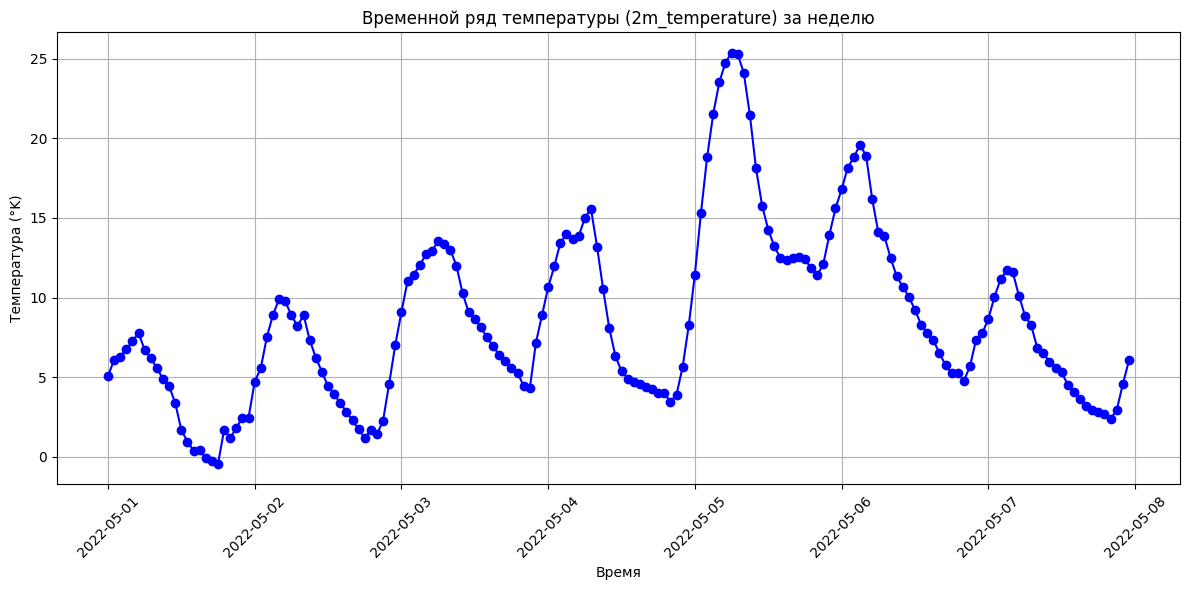

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Читаем CSV
csv_file = "temperature_timeseries.csv"
df = pd.read_csv(csv_file)

# Преобразуем время в datetime
df["time"] = pd.to_datetime(df["time"])

# Строим график
plt.figure(figsize=(12, 6))
plt.plot(df["time"], df["temperature"], marker="o", linestyle="-", color="b")
plt.title("Временной ряд температуры (2m_temperature) за неделю")
plt.xlabel("Время")
plt.ylabel("Температура (°K)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()